# LSST Time-Series Classification with Chronos-2

**Dataset**: LSST — 2459 train / 2466 test / 36 time steps / 6 channels / 14 classes  
**Approach**: Adapt the Chronos-2 forecasting TSFM as a frozen feature extractor, then train lightweight classifiers on top.

In [1]:
!pip install -q tslearn
!pip install -q "chronos-forecasting>=2.1.0"
!pip install -q tabicl


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 125.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 42.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.64.0 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.64.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.7/72.7 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 110.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.5/206.5 kB 19.2 MB/s eta

In [2]:
import gc
import math
import copy
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats as sp_stats
from scipy.signal import find_peaks

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.linear_model import RidgeClassifierCV
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

import lightgbm as lgb
from xgboost import XGBClassifier

import tslearn

warnings.filterwarnings("ignore")
SEED = 42


# 1. Data Loading & Preparation

In [3]:
from tslearn.datasets import UCR_UEA_datasets

ds = UCR_UEA_datasets()
X_train, y_train, X_test, y_test = ds.load_dataset("LSST")

print(f"Train X : {X_train.shape}, y : {y_train.shape}")
print(f"Test X : {X_test.shape}, y : {y_test.shape}")
print(f"Classes : {sorted(np.unique(y_train).tolist())}")


Train X : (2459, 36, 6), y : (2459,)
Test X : (2466, 36, 6), y : (2466,)
Classes : ['15', '16', '42', '52', '53', '6', '62', '64', '65', '67', '88', '90', '92', '95']


In [4]:
N_TRAIN, N_STEPS, N_CH = X_train.shape
N_TEST = X_test.shape[0]
N_CLASSES = len(np.unique(y_train))

print(f"Samples : {N_TRAIN} train / {N_TEST} test")
print(f"Length : {N_STEPS} time steps")
print(f"Channels : {N_CH}")
print(f"Classes : {N_CLASSES}")


Samples : 2459 train / 2466 test
Length : 36 time steps
Channels : 6
Classes : 14


In [5]:
# Encode labels as integers 0..13
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test  = le.transform(y_test)

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))


Label mapping: {np.str_('15'): np.int64(0), np.str_('16'): np.int64(1), np.str_('42'): np.int64(2), np.str_('52'): np.int64(3), np.str_('53'): np.int64(4), np.str_('6'): np.int64(5), np.str_('62'): np.int64(6), np.str_('64'): np.int64(7), np.str_('65'): np.int64(8), np.str_('67'): np.int64(9), np.str_('88'): np.int64(10), np.str_('90'): np.int64(11), np.str_('92'): np.int64(12), np.str_('95'): np.int64(13)}


In [6]:
class LSSTDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)   # (N, T, C)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 64

train_dataset = LSSTDataset(X_train, y_train)
test_dataset  = LSSTDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train batches : {len(train_loader)}  ({len(train_dataset)} samples)")
print(f"Test  batches : {len(test_loader)}  ({len(test_dataset)} samples)")


Train batches : 39  (2459 samples)
Test  batches : 39  (2466 samples)


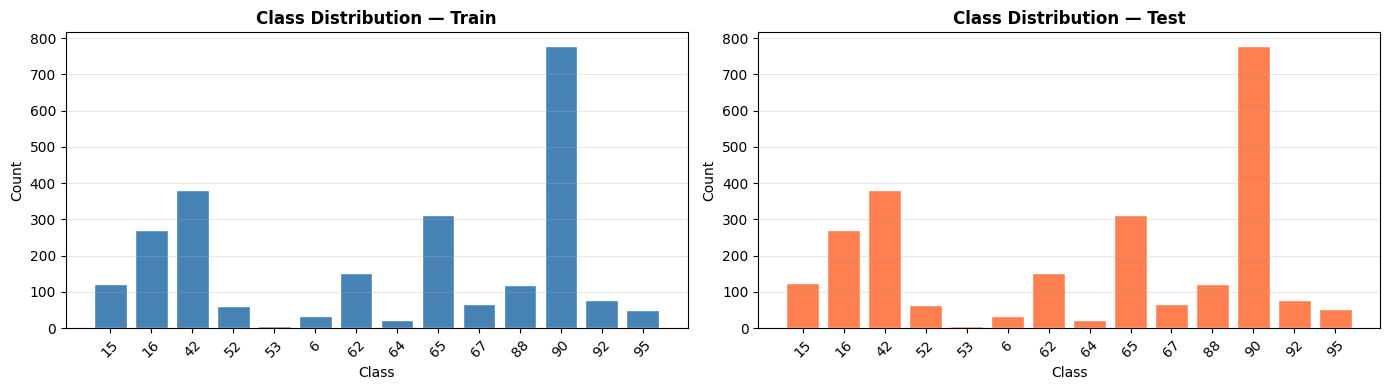

In [7]:
# Dataset overview plot
# Class distribution
class_counts_train = np.bincount(y_train)
class_counts_test  = np.bincount(y_test)
class_labels = [str(c) for c in le.classes_]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(class_labels, class_counts_train, color="steelblue", edgecolor="white")
axes[0].set_title("Class Distribution — Train", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(class_labels, class_counts_test, color="coral", edgecolor="white")
axes[1].set_title("Class Distribution — Test", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("fig_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


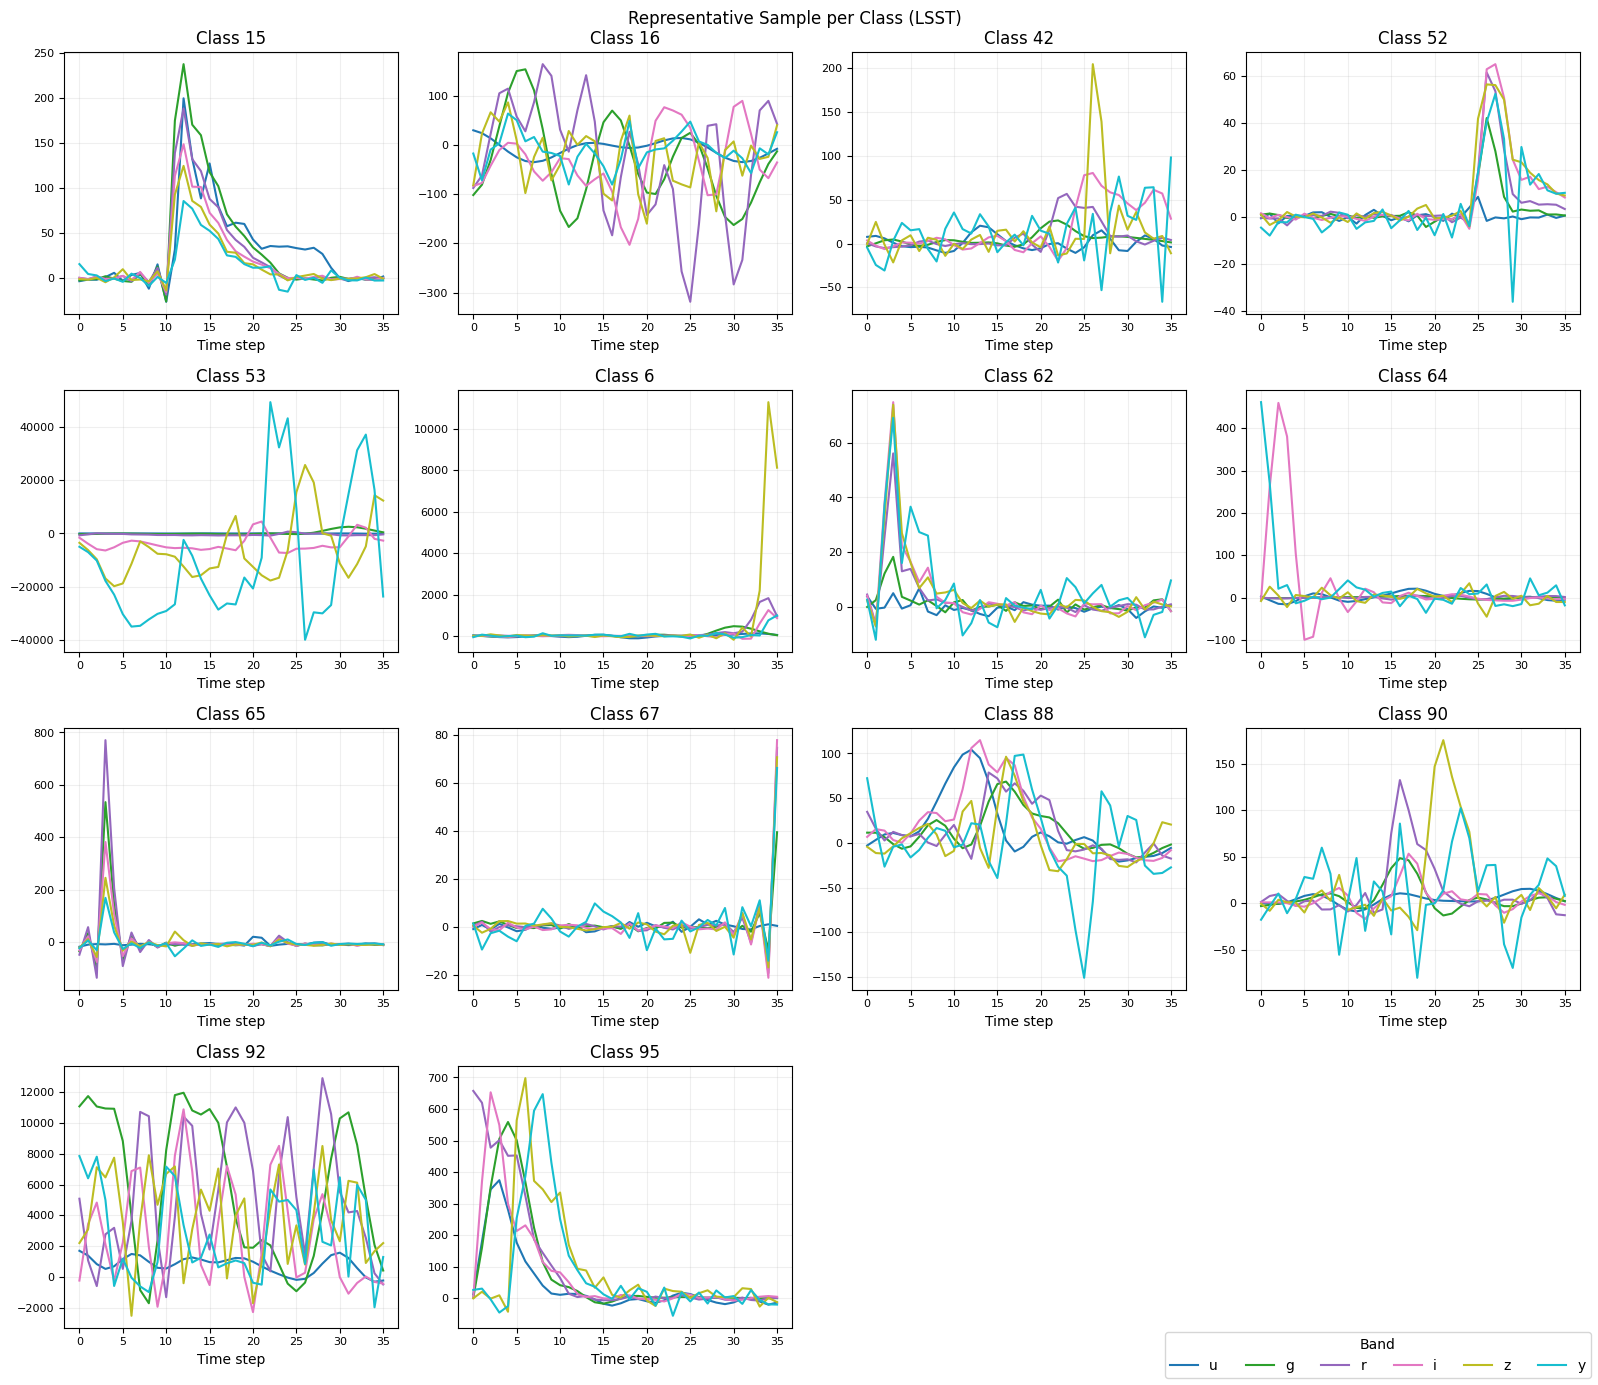

In [10]:
# Sample time series per class
BAND_NAMES = ["u", "g", "r", "i", "z", "y"]
n_cols = 4
n_rows = math.ceil(N_CLASSES / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows), sharey=False)
axes = np.array(axes).reshape(-1)
cmap = plt.cm.get_cmap("tab10", N_CH)

for cls_idx in range(N_CLASSES):
    ax = axes[cls_idx]
    sample_idx = np.where(y_train == cls_idx)[0][0]
    sample = X_train[sample_idx]  # (T, C)
    for c in range(N_CH):
        ax.plot(sample[:, c], label=BAND_NAMES[c], color=cmap(c))
    ax.set_title(f"Class {le.classes_[cls_idx]}")
    ax.set_xlabel("Time step")
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.2)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Band", loc="lower right", ncol=N_CH)

for ax in axes[N_CLASSES:]:
    ax.set_visible(False)

plt.suptitle("Representative Sample per Class (LSST)")
plt.tight_layout()
plt.savefig("fig_sample_per_class.png", dpi=150, bbox_inches="tight")
plt.show()


# 2. Handcrafted Features

Domain-inspired features inspired by the Avocado photometric classification pipeline, combining basic statistical descriptors with flux ratios and timing features.

In [11]:
def find_time_to_fractions(fluxes, fractions, forward=True):
    max_time = np.argmax(fluxes)
    max_flux = fluxes[max_time]
    result = np.zeros(len(fractions))
    frac_idx = 0
    offset = 0
    while True:
        offset += 1
        if forward:
            new_time = max_time + offset
            if new_time >= len(fluxes):
                result[frac_idx:] = offset
                break
        else:
            new_time = max_time - offset
            if new_time < 0:
                result[frac_idx:] = offset
                break
        test_flux = fluxes[new_time]
        while test_flux < max_flux * fractions[frac_idx]:
            result[frac_idx] = offset
            frac_idx += 1
            if frac_idx == len(fractions):
                break
        if frac_idx == len(fractions):
            break
    return result


def compute_handcrafted_features(X):
    """
    Compute per-sample handcrafted features from (N, T, C) array.
    Includes:
      - Per-channel statistics (mean, std, min, max, range, skew, kurtosis, slope, first/last)
      - Cross-channel correlations and amplitude ratios
      - Avocado features : flux ratios, timing, and percentile features
    """
    X = np.asarray(X, dtype=np.float32)
    if X.ndim != 3:
        raise ValueError(f"Expected (N, T, C), got {X.shape}")
    N, T, C = X.shape

    # LSST band indices: u=0, g=1, r=2, i=3, z=4, y=5
    b_g, b_i, b_y = 1, 3, 5
    feats = []

    for i in range(N):
        sf = []
        Xi = X[i]

        # Per-channel stats (10 per channel)
        for c in range(C):
            ts = Xi[:, c]
            sf.extend([
                np.mean(ts), np.std(ts), np.min(ts), np.max(ts), np.ptp(ts),
                float(sp_stats.skew(ts)), float(sp_stats.kurtosis(ts)),
                np.polyfit(np.arange(T), ts, 1)[0],
                ts[0], ts[-1],
            ])

        # Cross-channel correlations (C*(C-1)/2 = 15)
        for c1 in range(C):
            for c2 in range(c1 + 1, C):
                r = np.corrcoef(Xi[:, c1], Xi[:, c2])[0, 1]
                sf.append(r if np.isfinite(r) else 0.0)

        # Amplitude ratios (15)
        amps = [np.ptp(Xi[:, c]) for c in range(C)]
        for c1 in range(C):
            for c2 in range(c1 + 1, C):
                sf.append(np.log1p(amps[c1] / (amps[c2] + 1e-8)))

        # Avocado features
        mxi = np.max(Xi[:, b_i]);  mni = np.min(Xi[:, b_i])
        mxg = np.max(Xi[:, b_g]); mng = np.min(Xi[:, b_g])
        mxy = np.max(Xi[:, b_y]); mny = np.min(Xi[:, b_y])

        # magnitude associated with max flux in i band
        max_mag = -2.5 * np.log10(np.abs(mxi) + 1e-8)

        # ratio of peak flux to total positive excursion in i band
        pos_flux_ratio = mxi / (mxi - mni + 1e-8)

        # Compare peak/minimum flux between redder and bluer bands
        max_flux_ratio_red  = np.abs(mxy) / (np.abs(mxy) + np.abs(mxi) + 1e-8)
        max_flux_ratio_blue = np.abs(mxg) / (np.abs(mxi) + np.abs(mxg) + 1e-8)
        min_flux_ratio_red  = np.abs(mny) / (np.abs(mny) + np.abs(mni) + 1e-8)
        min_flux_ratio_blue = np.abs(mng) / (np.abs(mni) + np.abs(mng) + 1e-8)

        # delay between peaks in y and g bands
        max_dt = np.argmax(Xi[:, b_y]) - np.argmax(Xi[:, b_g])

        # rough duration of positive / negative parts in i band
        pos_width = np.sum(np.clip(Xi[:, b_i], 0, None)) / (mxi + 1e-8)
        neg_width = np.sum(np.clip(Xi[:, b_i], None, 0)) / (mni - 1e-8)

        sf.extend([max_mag, pos_flux_ratio, max_flux_ratio_red, max_flux_ratio_blue,
                   min_flux_ratio_red, min_flux_ratio_blue, max_dt, pos_width, neg_width])

        # Peak decay/rise timing features
        # Time needed to fall below 50% and 20% of the peak
        fracs = [0.5, 0.2]

        fwd_i = find_time_to_fractions(Xi[:, b_i], fracs, True)
        bwd_i = find_time_to_fractions(Xi[:, b_i], fracs, False)

        fwd_g = find_time_to_fractions(Xi[:, b_g], fracs, True)
        bwd_g = find_time_to_fractions(Xi[:, b_g], fracs, False)

        fwd_y = find_time_to_fractions(Xi[:, b_y], fracs, True)
        bwd_y = find_time_to_fractions(Xi[:, b_y], fracs, False)

        # Absolute times in i band + normalized comparisons with g and y bands
        sf.extend([
            fwd_i[0], fwd_i[1],
            fwd_y[0]/(fwd_y[0]+fwd_i[0]+1e-8), fwd_g[0]/(fwd_g[0]+fwd_i[0]+1e-8),
            fwd_y[1]/(fwd_y[1]+fwd_i[1]+1e-8), fwd_g[1]/(fwd_g[1]+fwd_i[1]+1e-8),
            bwd_i[0], bwd_i[1],
            bwd_y[0]/(bwd_y[0]+bwd_i[0]+1e-8), bwd_g[0]/(bwd_g[0]+bwd_i[0]+1e-8),
            bwd_y[1]/(bwd_y[1]+bwd_i[1]+1e-8), bwd_g[1]/(bwd_g[1]+bwd_i[1]+1e-8),
        ])

        # Percentile differences
        pcts = [10, 30, 50, 70, 90]
        fp = []
        for p in pcts:
            vals = [(np.percentile(Xi[:, c], p) - np.min(Xi[:, c])) /
                    (np.ptp(Xi[:, c]) + 1e-8) for c in range(C)]
            fp.append(np.nanmedian(vals))
        sf.extend([fp[0]-fp[2], fp[1]-fp[2], fp[3]-fp[2], fp[4]-fp[2]])

        # Secondary peak strength
        pk_fracs = []
        for c in range(C):
            flux = Xi[:, c]
            pks, props = find_peaks(flux, height=np.max(np.abs(flux))/5.0)
            h = np.sort(props["peak_heights"])[::-1]
            pk_fracs.append(h[1]/h[0] if len(h) > 1 else 0.0)
        sf.append(np.nanmedian(pk_fracs))

        feats.append(sf)

    return np.nan_to_num(np.array(feats, dtype=np.float32), nan=0.0, posinf=0.0, neginf=0.0)


def clean(arr):
    return np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)


In [12]:
hc_train = compute_handcrafted_features(X_train)
hc_test  = compute_handcrafted_features(X_test)

print(f"Handcrafted train shape : {hc_train.shape}")
print(f"Handcrafted test  shape : {hc_test.shape}")


Handcrafted train shape : (2459, 116)
Handcrafted test  shape : (2466, 116)


# 3. Chronos-2 Feature Extractor

## 3.1 Intermediate Layer Pipeline

We override Chronos-2's encoder to collect hidden states at any intermediate block, enabling layer-depth ablation studies.

In [13]:
from chronos import Chronos2Pipeline
from chronos.chronos2.dataset import Chronos2Dataset, DatasetMode


class Chronos2IntermediatePipeline(Chronos2Pipeline):
    """Subclass of Chronos2Pipeline that exposes intermediate encoder hidden states."""

    @staticmethod
    def _to_chronos_dict_inputs(inputs):
        if isinstance(inputs, np.ndarray):
            inputs = torch.from_numpy(inputs)
        if isinstance(inputs, torch.Tensor):
            if inputs.ndim != 3:
                raise ValueError(f"Expected 3D tensor (B, C, T), got {tuple(inputs.shape)}")
            return [{"target": inputs[i].detach().cpu()} for i in range(inputs.shape[0])]
        if isinstance(inputs, (list, tuple)):
            out = []
            for i, x in enumerate(inputs):
                if isinstance(x, np.ndarray):
                    x = torch.from_numpy(x)
                if x.ndim == 1:
                    x = x.unsqueeze(0)
                out.append({"target": x.detach().cpu()})
            return out
        raise TypeError(f"Unsupported input type: {type(inputs)}")

    @torch.no_grad()
    def _encode_and_collect_layer(self, context, group_ids=None, layer_idx=7,
                                   apply_final_norm=False):
        """
        Runs the encoder manually to collect the hidden state after a specific block.

        layer_idx: 0..11 for intermediate blocks, -1 for final normed output.
        """
        model   = self.model
        encoder = model.encoder

        model._validate_input(
            context=context, context_mask=None,
            future_covariates=None, future_covariates_mask=None,
            group_ids=group_ids, num_output_patches=1,
            future_target=None, future_target_mask=None,
        )

        batch_size = context.shape[0]
        patched_context, attention_mask, loc_scale = model._prepare_patched_context(
            context=context, context_mask=None)

        input_embeds = model.input_patch_embedding(patched_context)

        if model.chronos_config.use_reg_token:
            reg_ids = torch.full((batch_size, 1), model.config.reg_token_id,
                                  device=input_embeds.device)
            reg_embs = model.shared(reg_ids)
            input_embeds = torch.cat([input_embeds, reg_embs], dim=-2)
            attention_mask = torch.cat(
                [attention_mask.to(model.dtype),
                 torch.ones_like(reg_ids).to(model.dtype)], dim=-1)

        patched_future, _ = model._prepare_patched_future(
            future_covariates=None, future_covariates_mask=None,
            loc_scale=loc_scale, num_output_patches=1, batch_size=batch_size)

        future_attn = torch.ones(batch_size, 1, dtype=model.dtype, device=model.device)
        future_embs = model.input_patch_embedding(patched_future)
        input_embeds = torch.cat([input_embeds, future_embs], dim=-2)
        attention_mask = torch.cat([attention_mask, future_attn], dim=-1)

        if group_ids is None:
            group_ids = torch.arange(batch_size, dtype=torch.long, device=model.device)

        seq_length = input_embeds.size(1)
        position_ids = torch.arange(0, seq_length, dtype=torch.long,
                                     device=input_embeds.device).unsqueeze(0)

        ext_attn  = encoder._expand_and_invert_time_attention_mask(attention_mask, input_embeds.dtype)
        group_mask = encoder._construct_and_invert_group_time_mask(group_ids, attention_mask, input_embeds.dtype)

        hidden = encoder.dropout(input_embeds)
        layer_hiddens = []
        for block in encoder.block:
            out = block(hidden, position_ids=position_ids,
                        attention_mask=ext_attn, group_time_mask=group_mask,
                        output_attentions=False)
            hidden = out.hidden_states
            layer_hiddens.append(hidden)

        final_hidden = encoder.dropout(encoder.final_layer_norm(hidden))

        if layer_idx == -1:
            chosen = final_hidden
        else:
            chosen = layer_hiddens[layer_idx]
            if apply_final_norm:
                chosen = encoder.dropout(encoder.final_layer_norm(chosen))

        return chosen, loc_scale

    @torch.no_grad()
    def embed_from_layer(self, inputs, batch_size=256, context_length=None, layer_idx=7):
        """Return per-sample embeddings from a specific encoder layer."""
        if context_length is None:
            context_length = self.model_context_length

        inputs = self._to_chronos_dict_inputs(inputs)

        dataset = Chronos2Dataset(
            inputs=inputs, context_length=context_length, prediction_length=0,
            batch_size=batch_size, output_patch_size=self.model_output_patch_size,
            mode=DatasetMode.TEST,
        )

        loader = DataLoader(dataset, batch_size=None, num_workers=0,
                            pin_memory=self.model.device.type == "cuda",
                            shuffle=False, drop_last=False)

        all_embeds, all_loc_scales = [], []
        for batch in loader:
            ctx  = batch["context"]
            gids = batch["group_ids"]
            ranges = batch["target_idx_ranges"]

            chosen, (locs, scales) = self._encode_and_collect_layer(
                context=ctx.to(device=self.model.device, dtype=torch.float32),
                group_ids=gids.to(self.model.device),
                layer_idx=layer_idx,
            )
            all_embeds.extend([chosen[s:e].detach().cpu() for s, e in ranges])
            all_loc_scales.extend(zip(
                [locs[s:e].detach().cpu() for s, e in ranges],
                [scales[s:e].detach().cpu() for s, e in ranges],
            ))

        return all_embeds, all_loc_scales


## 3.2 Feature Extractor Module

Pooling strategies tested:
- reg_plus_patch : concatenate REG token + mean of patch tokens
- mean_all : mean over all tokens
- reg : REG token only

In [86]:
class Chronos2FeatureExtractor(nn.Module):
    """
    Frozen Chronos-2 feature extractor with configurable layer and pooling mode.

    pool_mode options:
        - 'reg_plus_patch' : [REG, mean(patches + future)] concatenated
        - 'mean_all'       : mean over all tokens
        - 'reg'            : REG token only
        - 'stats'          : [REG, mean(patches), max(patches), min(patches)]
    """

    def __init__(
        self,
        input_channels: int = 6,
        chronos_model_name: str = "amazon/chronos-2",
        layer_idx: int = 7,
        pool_mode: str = "reg_plus_patch",
        batch_size_embed: int = 256,
        context_length=None,
        drop_mask_token: bool = False,
    ):
        super().__init__()
        self.input_channels    = input_channels
        self.layer_idx         = layer_idx
        self.pool_mode         = pool_mode
        self.batch_size_embed  = batch_size_embed
        self.context_length    = context_length
        self.drop_mask_token   = drop_mask_token

        chronos_device = "cuda" if torch.cuda.is_available() else "cpu"
        chronos_dtype  = torch.bfloat16 if chronos_device == "cuda" else torch.float32

        self.pipeline = Chronos2IntermediatePipeline.from_pretrained(
            chronos_model_name, device_map=chronos_device, dtype=chronos_dtype)

        for p in self.pipeline.model.parameters():
            p.requires_grad = False
        self.eval()

    @torch.no_grad()
    def _pool(self, emb: torch.Tensor) -> torch.Tensor:
        """emb: (C, num_tokens, d_model)"""
        # Token layout: [patch_1, ..., patch_N, REG, MASK]
        patch_tokens  = emb[:, :-2, :]   # (C, P, D)
        reg_tokens    = emb[:, -2,  :]   # (C, D)
        future_token  = emb[:, -1:, :]   # (C, 1, D)

        if self.pool_mode == "reg":
            return reg_tokens.reshape(-1)
        elif self.pool_mode == "mean_all":
            return emb.mean(dim=1).reshape(-1)
        elif self.pool_mode == "reg_plus_patch":
            pooled = torch.cat([patch_tokens, future_token], dim=1).mean(dim=1)
            return torch.cat([reg_tokens, pooled], dim=-1).reshape(-1)
        elif self.pool_mode == "mean_patch_mask":
            pooled = torch.cat([patch_tokens, future_token], dim=1).mean(dim=1)
            return pooled.reshape(-1)
        elif self.pool_mode == "stats":
            m = patch_tokens.mean(dim=1)
            mx = patch_tokens.max(dim=1).values
            mn = patch_tokens.min(dim=1).values
            return torch.cat([reg_tokens, m, mx, mn], dim=-1).reshape(-1)
        else:
            raise ValueError(f"Unknown pool_mode: {self.pool_mode}")

    @torch.no_grad()
    def extract_embeddings(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, T, C) → (B, feature_dim)"""
        x_perm = x.permute(0, 2, 1).contiguous()   # (B, C, T)
        embeddings, _ = self.pipeline.embed_from_layer(
            inputs=x_perm,
            batch_size=self.batch_size_embed,
            context_length=self.context_length,
            layer_idx=self.layer_idx,
        )
        pooled = [self._pool(e) for e in embeddings]
        return torch.stack(pooled, dim=0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.extract_embeddings(x).to(dtype=torch.float32)


@torch.no_grad()
def get_all_embeddings(loader, model, device):
    all_feats, all_labels = [], []
    model.eval()
    print("Extracting embeddings...")
    for xb, yb in loader:
        xb = xb.to(device)
        all_feats.append(model(xb).cpu().numpy())
        all_labels.append(yb.cpu().numpy())
    X = np.vstack(all_feats)
    y = np.concatenate(all_labels)
    return np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0), y


# 4. Layer-Depth Ablation Study

Sweep encoder layers 0–11 plus final normed output (–1) for two pooling strategies, using Ridge and a fast XGBoost probe. This identifies the optimal feature extraction depth.

## 4.1 Pool mode: reg_plus_patch, Ridge probe

### Ridge

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

layer_idx_list = list(range(12)) + [-1]

# Pre-compute handcrafted features once (reused in all ablations)
hc_train = compute_handcrafted_features(X_train)
hc_test  = compute_handcrafted_features(X_test)

results_reg_patch_ridge = {}
acc_rpr, f1_rpr, bacc_rpr = [], [], []

for layer in layer_idx_list:
    print(f"\nLayer {layer}")

    extractor = Chronos2FeatureExtractor(
        input_channels=N_CH, chronos_model_name="amazon/chronos-2",
        layer_idx=layer, pool_mode="reg_plus_patch",
        batch_size_embed=256, drop_mask_token=False,
    ).to(device)

    X_tr, y_tr = get_all_embeddings(train_loader, extractor, device)
    X_te, y_te = get_all_embeddings(test_loader,  extractor, device)

    C_tr = clean(np.concatenate([X_tr, hc_train], axis=1))
    C_te = clean(np.concatenate([X_te, hc_test],  axis=1))

    clf = make_pipeline(StandardScaler(), RidgeClassifierCV(alphas=np.logspace(-3, 3, 13)))
    clf.fit(C_tr, y_tr)
    y_pred = clf.predict(C_te)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average="macro")
    bacc = balanced_accuracy_score(y_te, y_pred)

    acc_rpr.append(acc); f1_rpr.append(f1); bacc_rpr.append(bacc)
    results_reg_patch_ridge[layer] = dict(accuracy=acc, macro_f1=f1, balanced_accuracy=bacc)
    print(f"  acc={acc:.4f}  bacc={bacc:.4f}  macro_f1={f1:.4f}")

    del extractor; gc.collect(); torch.cuda.empty_cache()



Layer 0


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/478M [00:00<?, ?B/s]

Extracting embeddings...
Extracting embeddings...
  acc=0.6529  bacc=0.4282  macro_f1=0.4451

Layer 1
Extracting embeddings...
Extracting embeddings...
  acc=0.6500  bacc=0.4162  macro_f1=0.4342

Layer 2
Extracting embeddings...
Extracting embeddings...
  acc=0.6569  bacc=0.4358  macro_f1=0.4571

Layer 3
Extracting embeddings...
Extracting embeddings...
  acc=0.6549  bacc=0.4372  macro_f1=0.4600

Layer 4
Extracting embeddings...
Extracting embeddings...
  acc=0.6606  bacc=0.4373  macro_f1=0.4559

Layer 5
Extracting embeddings...
Extracting embeddings...
  acc=0.6557  bacc=0.4397  macro_f1=0.4599

Layer 6
Extracting embeddings...
Extracting embeddings...
  acc=0.6622  bacc=0.4320  macro_f1=0.4514

Layer 7
Extracting embeddings...
Extracting embeddings...
  acc=0.6610  bacc=0.4536  macro_f1=0.4718

Layer 8
Extracting embeddings...
Extracting embeddings...
  acc=0.6577  bacc=0.4531  macro_f1=0.4722

Layer 9
Extracting embeddings...
Extracting embeddings...
  acc=0.6521  bacc=0.4492  macro

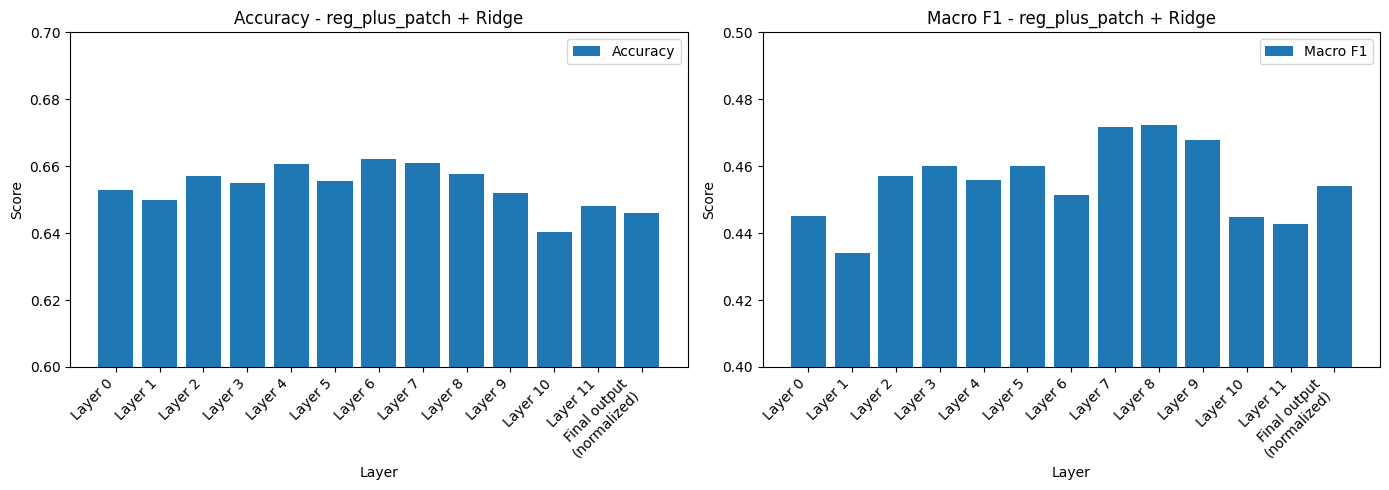

In [33]:
# Plot: reg_plus_patch / Ridge
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_labels = [
    "Final output\n(normalized)" if x == -1 else f"Layer {x}"
    for x in layer_idx_list
]

# Accuracy
axes[0].bar(range(len(layer_idx_list)), acc_rpr, label="Accuracy")
axes[0].set_ylim(0.6, 0.7)
axes[0].set_xticks(range(len(layer_idx_list)))
axes[0].set_xticklabels(x_labels, rotation=45, ha="right")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Score")
axes[0].set_title("Accuracy - reg_plus_patch + Ridge")
axes[0].legend()

# Macro F1 bar plot
axes[1].bar(range(len(layer_idx_list)), f1_rpr, label="Macro F1")
axes[1].set_ylim(0.4, 0.5)
axes[1].set_xticks(range(len(layer_idx_list)))
axes[1].set_xticklabels(x_labels, rotation=45, ha="right")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Score")
axes[1].set_title("Macro F1 - reg_plus_patch + Ridge")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_ablation_reg_plus_patch_ridge.png", dpi=150, bbox_inches="tight")
plt.show()

### Xgboost

In [64]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

layer_idx_list = list(range(12)) + [-1]

# Pre-compute handcrafted features once (reused in all ablations)
hc_train = compute_handcrafted_features(X_train)
hc_test  = compute_handcrafted_features(X_test)

results_reg_patch_ridge = {}
acc_rpr, f1_rpr, bacc_rpr = [], [], []

for layer in layer_idx_list:
    print(f"\nLayer {layer}")

    extractor = Chronos2FeatureExtractor(
        input_channels=N_CH, chronos_model_name="amazon/chronos-2",
        layer_idx=layer, pool_mode="reg_plus_patch",
        batch_size_embed=256, drop_mask_token=False,
    ).to(device)

    X_tr, y_tr = get_all_embeddings(train_loader, extractor, device)
    X_te, y_te = get_all_embeddings(test_loader,  extractor, device)

    C_tr = clean(np.concatenate([X_tr, hc_train], axis=1))
    C_te = clean(np.concatenate([X_te, hc_test],  axis=1))

    classes = np.unique(y_train)
    wts = compute_class_weight("balanced", classes=classes, y=y_train)
    cwd = dict(zip(classes, wts))

    sw = np.array([cwd[y] for y in y_train], dtype=np.float32)

    xgb_clf = XGBClassifier(
        n_estimators=25, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, tree_method="hist", eval_metric="mlogloss",
    )
    xgb_clf.fit(C_tr, y_train, sample_weight=sw)
    y_pred = xgb_clf.predict(C_te)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average="macro")
    bacc = balanced_accuracy_score(y_te, y_pred)

    acc_rpr.append(acc); f1_rpr.append(f1); bacc_rpr.append(bacc)
    results_reg_patch_ridge[layer] = dict(accuracy=acc, macro_f1=f1, balanced_accuracy=bacc)
    print(f"  acc={acc:.4f}  bacc={bacc:.4f}  macro_f1={f1:.4f}")

    del extractor; gc.collect(); torch.cuda.empty_cache()



Layer 0
Extracting embeddings...
Extracting embeddings...
  acc=0.6456  bacc=0.5234  macro_f1=0.5275

Layer 1
Extracting embeddings...
Extracting embeddings...
  acc=0.6480  bacc=0.5172  macro_f1=0.5146

Layer 2
Extracting embeddings...
Extracting embeddings...
  acc=0.6509  bacc=0.5318  macro_f1=0.5239

Layer 3
Extracting embeddings...
Extracting embeddings...
  acc=0.6517  bacc=0.5103  macro_f1=0.5110

Layer 4
Extracting embeddings...
Extracting embeddings...
  acc=0.6667  bacc=0.5398  macro_f1=0.5403

Layer 5
Extracting embeddings...
Extracting embeddings...
  acc=0.6610  bacc=0.5298  macro_f1=0.5406

Layer 6
Extracting embeddings...
Extracting embeddings...
  acc=0.6582  bacc=0.5264  macro_f1=0.5263

Layer 7
Extracting embeddings...
Extracting embeddings...
  acc=0.6521  bacc=0.5141  macro_f1=0.5204

Layer 8
Extracting embeddings...
Extracting embeddings...
  acc=0.6504  bacc=0.5044  macro_f1=0.5025

Layer 9
Extracting embeddings...
Extracting embeddings...
  acc=0.6638  bacc=0.53

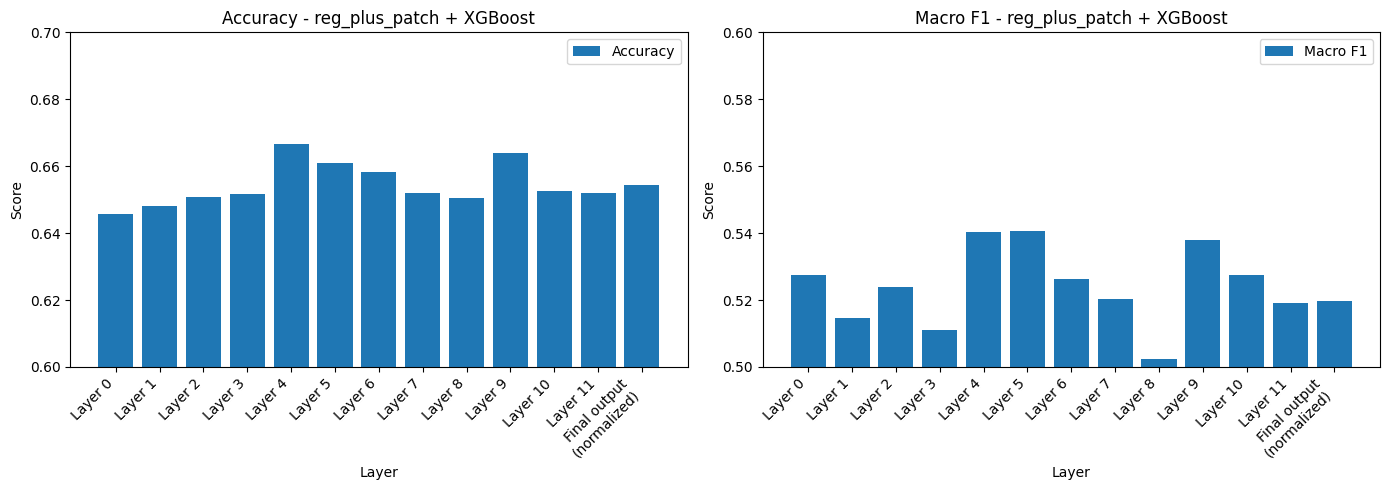

In [84]:
# Plot: reg_plus_patch / XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_labels = [
    "Final output\n(normalized)" if x == -1 else f"Layer {x}"
    for x in layer_idx_list
]

# Accuracy
axes[0].bar(range(len(layer_idx_list)), acc_rpr, label="Accuracy")
axes[0].set_ylim(0.6, 0.7)
axes[0].set_xticks(range(len(layer_idx_list)))
axes[0].set_xticklabels(x_labels, rotation=45, ha="right")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Score")
axes[0].set_title("Accuracy - reg_plus_patch + XGBoost")
axes[0].legend()

# Macro F1 bar plot
axes[1].bar(range(len(layer_idx_list)), f1_rpr, label="Macro F1")
axes[1].set_ylim(0.5, 0.6)
axes[1].set_xticks(range(len(layer_idx_list)))
axes[1].set_xticklabels(x_labels, rotation=45, ha="right")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Score")
axes[1].set_title("Macro F1 - reg_plus_patch + XGBoost")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_ablation_reg_plus_patch_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

## 4.2 Pool mode: mean_all, Ridge probe

### Ridge

In [27]:
results_mean_all_ridge = {}
acc_mar, f1_mar, bacc_mar = [], [], []

for layer in layer_idx_list:
    print(f"\nLayer {layer}")

    extractor = Chronos2FeatureExtractor(
        input_channels=N_CH, chronos_model_name="amazon/chronos-2",
        layer_idx=layer, pool_mode="mean_all",
        batch_size_embed=256, drop_mask_token=False,
    ).to(device)

    X_tr, y_tr = get_all_embeddings(train_loader, extractor, device)
    X_te, y_te = get_all_embeddings(test_loader,  extractor, device)

    C_tr = clean(np.concatenate([X_tr, hc_train], axis=1))
    C_te = clean(np.concatenate([X_te, hc_test],  axis=1))

    clf = make_pipeline(StandardScaler(), RidgeClassifierCV(alphas=np.logspace(-3, 3, 13)))
    clf.fit(C_tr, y_tr)
    y_pred = clf.predict(C_te)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average="macro")
    bacc = balanced_accuracy_score(y_te, y_pred)

    acc_mar.append(acc); f1_mar.append(f1); bacc_mar.append(bacc)
    results_mean_all_ridge[layer] = dict(accuracy=acc, macro_f1=f1, balanced_accuracy=bacc)
    print(f"  acc={acc:.4f}  bacc={bacc:.4f}  macro_f1={f1:.4f}")

    del extractor; gc.collect(); torch.cuda.empty_cache()



Layer 0
Extracting embeddings...
Extracting embeddings...
  acc=0.6504  bacc=0.4308  macro_f1=0.4471

Layer 1
Extracting embeddings...
Extracting embeddings...
  acc=0.6553  bacc=0.4287  macro_f1=0.4459

Layer 2
Extracting embeddings...
Extracting embeddings...
  acc=0.6606  bacc=0.4462  macro_f1=0.4621

Layer 3
Extracting embeddings...
Extracting embeddings...
  acc=0.6598  bacc=0.4386  macro_f1=0.4586

Layer 4
Extracting embeddings...
Extracting embeddings...
  acc=0.6630  bacc=0.4388  macro_f1=0.4566

Layer 5
Extracting embeddings...
Extracting embeddings...
  acc=0.6659  bacc=0.4406  macro_f1=0.4584

Layer 6
Extracting embeddings...
Extracting embeddings...
  acc=0.6638  bacc=0.4300  macro_f1=0.4434

Layer 7
Extracting embeddings...
Extracting embeddings...
  acc=0.6626  bacc=0.4476  macro_f1=0.4631

Layer 8
Extracting embeddings...
Extracting embeddings...
  acc=0.6610  bacc=0.4483  macro_f1=0.4625

Layer 9
Extracting embeddings...
Extracting embeddings...
  acc=0.6557  bacc=0.45

In [87]:
results_mean_all_ridge = {}
acc_mar, f1_mar, bacc_mar = [], [], []

for layer in layer_idx_list:
    print(f"\nLayer {layer}")

    extractor = Chronos2FeatureExtractor(
        input_channels=N_CH, chronos_model_name="amazon/chronos-2",
        layer_idx=layer, pool_mode="mean_patch_mask",
        batch_size_embed=256, drop_mask_token=False,
    ).to(device)

    X_tr, y_tr = get_all_embeddings(train_loader, extractor, device)
    X_te, y_te = get_all_embeddings(test_loader,  extractor, device)

    C_tr = clean(np.concatenate([X_tr, hc_train], axis=1))
    C_te = clean(np.concatenate([X_te, hc_test],  axis=1))

    clf = make_pipeline(StandardScaler(), RidgeClassifierCV(alphas=np.logspace(-3, 3, 13)))
    clf.fit(C_tr, y_tr)
    y_pred = clf.predict(C_te)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average="macro")
    bacc = balanced_accuracy_score(y_te, y_pred)

    acc_mar.append(acc); f1_mar.append(f1); bacc_mar.append(bacc)
    results_mean_all_ridge[layer] = dict(accuracy=acc, macro_f1=f1, balanced_accuracy=bacc)
    print(f"  acc={acc:.4f}  bacc={bacc:.4f}  macro_f1={f1:.4f}")

    del extractor; gc.collect(); torch.cuda.empty_cache()



Layer 0
Extracting embeddings...
Extracting embeddings...
  acc=0.6541  bacc=0.4286  macro_f1=0.4457

Layer 1
Extracting embeddings...
Extracting embeddings...
  acc=0.6561  bacc=0.4192  macro_f1=0.4346

Layer 2
Extracting embeddings...
Extracting embeddings...
  acc=0.6618  bacc=0.4494  macro_f1=0.4669

Layer 3
Extracting embeddings...
Extracting embeddings...
  acc=0.6577  bacc=0.4339  macro_f1=0.4534

Layer 4
Extracting embeddings...
Extracting embeddings...
  acc=0.6634  bacc=0.4398  macro_f1=0.4589

Layer 5
Extracting embeddings...
Extracting embeddings...
  acc=0.6663  bacc=0.4541  macro_f1=0.4717

Layer 6
Extracting embeddings...
Extracting embeddings...
  acc=0.6715  bacc=0.4464  macro_f1=0.4665

Layer 7
Extracting embeddings...
Extracting embeddings...
  acc=0.6642  bacc=0.4493  macro_f1=0.4645

Layer 8
Extracting embeddings...
Extracting embeddings...
  acc=0.6622  bacc=0.4522  macro_f1=0.4696

Layer 9
Extracting embeddings...
Extracting embeddings...
  acc=0.6541  bacc=0.44

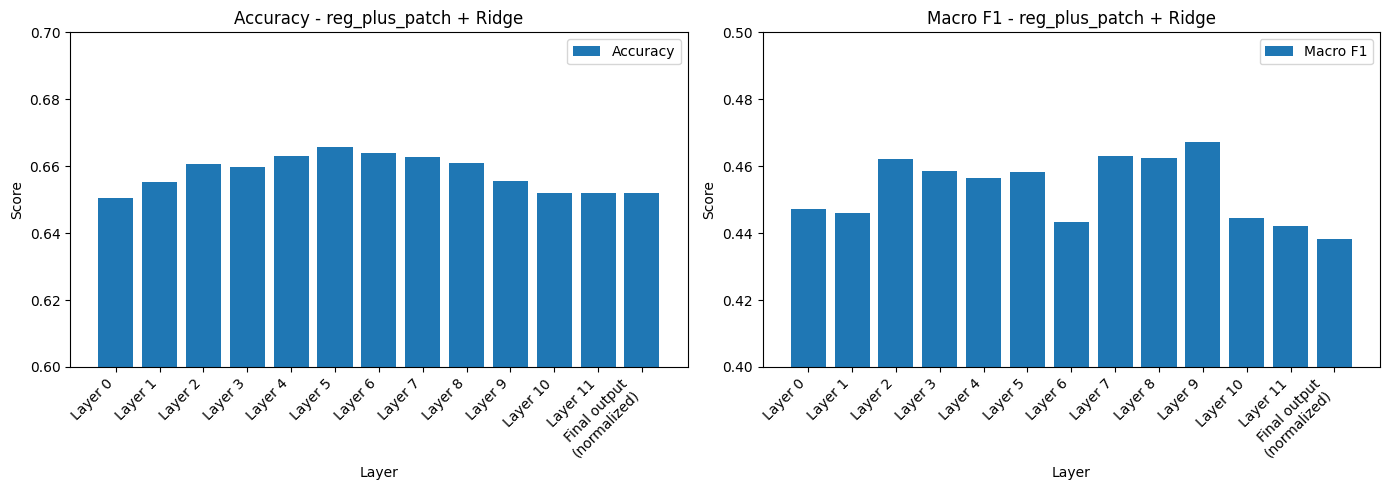

In [32]:
# Plot: reg_plus_patch / Ridge
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_labels = [
    "Final output\n(normalized)" if x == -1 else f"Layer {x}"
    for x in layer_idx_list
]

# Accuracy
axes[0].bar(range(len(layer_idx_list)), acc_mar, label="Accuracy")
axes[0].set_ylim(0.6, 0.7)
axes[0].set_xticks(range(len(layer_idx_list)))
axes[0].set_xticklabels(x_labels, rotation=45, ha="right")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Score")
axes[0].set_title("Accuracy - mean_all + Ridge")
axes[0].legend()

# Macro F1
axes[1].bar(range(len(layer_idx_list)), f1_mar, label="Macro F1")
axes[1].set_ylim(0.4, 0.5)
axes[1].set_xticks(range(len(layer_idx_list)))
axes[1].set_xticklabels(x_labels, rotation=45, ha="right")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Score")
axes[1].set_title("Macro F1 - mean_all + Ridge")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_ablation_reg_all_ridge.png", dpi=150, bbox_inches="tight")
plt.show()

### xgboost

In [57]:
results_mean_all_ridge = {}
acc_mar, f1_mar, bacc_mar = [], [], []

for layer in layer_idx_list:
    print(f"\nLayer {layer}")

    extractor = Chronos2FeatureExtractor(
        input_channels=N_CH, chronos_model_name="amazon/chronos-2",
        layer_idx=layer, pool_mode="mean_all",
        batch_size_embed=256, drop_mask_token=False,
    ).to(device)

    X_tr, y_tr = get_all_embeddings(train_loader, extractor, device)
    X_te, y_te = get_all_embeddings(test_loader,  extractor, device)

    C_tr = clean(np.concatenate([X_tr, hc_train], axis=1))
    C_te = clean(np.concatenate([X_te, hc_test],  axis=1))

    classes = np.unique(y_train)
    wts = compute_class_weight("balanced", classes=classes, y=y_train)
    cwd = dict(zip(classes, wts))

    sw = np.array([cwd[y] for y in y_train], dtype=np.float32)

    xgb_clf = XGBClassifier(
        n_estimators=25, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, tree_method="hist", eval_metric="mlogloss",
    )
    xgb_clf.fit(C_tr, y_train, sample_weight=sw)
    y_pred = xgb_clf.predict(C_te)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average="macro")
    bacc = balanced_accuracy_score(y_te, y_pred)

    acc_mar.append(acc); f1_mar.append(f1); bacc_mar.append(bacc)
    results_mean_all_ridge[layer] = dict(accuracy=acc, macro_f1=f1, balanced_accuracy=bacc)
    print(f"  acc={acc:.4f}  bacc={bacc:.4f}  macro_f1={f1:.4f}")

    del extractor; gc.collect(); torch.cuda.empty_cache()



Layer 0
Extracting embeddings...
Extracting embeddings...
  acc=0.6448  bacc=0.5049  macro_f1=0.5035

Layer 1
Extracting embeddings...
Extracting embeddings...
  acc=0.6468  bacc=0.5356  macro_f1=0.5365

Layer 2
Extracting embeddings...
Extracting embeddings...
  acc=0.6553  bacc=0.5258  macro_f1=0.5212

Layer 3
Extracting embeddings...
Extracting embeddings...
  acc=0.6521  bacc=0.5211  macro_f1=0.5240

Layer 4
Extracting embeddings...
Extracting embeddings...
  acc=0.6496  bacc=0.5336  macro_f1=0.5392

Layer 5
Extracting embeddings...
Extracting embeddings...
  acc=0.6545  bacc=0.5462  macro_f1=0.5545

Layer 6
Extracting embeddings...
Extracting embeddings...
  acc=0.6561  bacc=0.5335  macro_f1=0.5336

Layer 7
Extracting embeddings...
Extracting embeddings...
  acc=0.6638  bacc=0.5402  macro_f1=0.5479

Layer 8
Extracting embeddings...
Extracting embeddings...
  acc=0.6460  bacc=0.5283  macro_f1=0.5311

Layer 9
Extracting embeddings...
Extracting embeddings...
  acc=0.6464  bacc=0.53

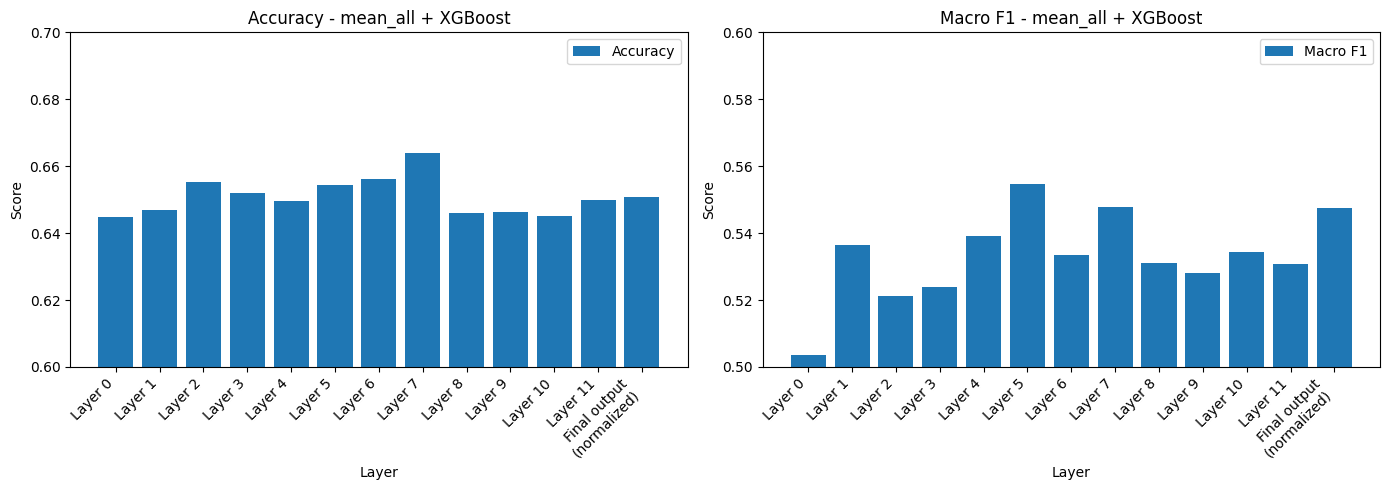

In [60]:
# Plot: reg_plus_patch / XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_labels = [
    "Final output\n(normalized)" if x == -1 else f"Layer {x}"
    for x in layer_idx_list
]

# Accuracy
axes[0].bar(range(len(layer_idx_list)), acc_mar, label="Accuracy")
axes[0].set_ylim(0.6, 0.7)
axes[0].set_xticks(range(len(layer_idx_list)))
axes[0].set_xticklabels(x_labels, rotation=45, ha="right")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Score")
axes[0].set_title("Accuracy - mean_all + XGBoost")
axes[0].legend()

# Macro F1
axes[1].bar(range(len(layer_idx_list)), f1_mar, label="Macro F1")
axes[1].set_ylim(0.5, 0.6)
axes[1].set_xticks(range(len(layer_idx_list)))
axes[1].set_xticklabels(x_labels, rotation=45, ha="right")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Score")
axes[1].set_title("Macro F1 - mean_all + XGBoost")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_ablation_mean_all_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

## 4.3 Pool mode: REG token only, Ridge probe

### Ridge

In [30]:
results_reg_xgb = {}
acc_rxgb, f1_rxgb, bacc_rxgb = [], [], []

for layer in layer_idx_list:
    print(f"\nLayer {layer}")

    extractor = Chronos2FeatureExtractor(
        input_channels=N_CH, chronos_model_name="amazon/chronos-2",
        layer_idx=layer, pool_mode="reg",
        batch_size_embed=256, drop_mask_token=False,
    ).to(device)

    X_tr, y_tr = get_all_embeddings(train_loader, extractor, device)
    X_te, y_te = get_all_embeddings(test_loader,  extractor, device)

    C_tr = clean(np.concatenate([X_tr, hc_train], axis=1))
    C_te = clean(np.concatenate([X_te, hc_test],  axis=1))

    classes = np.unique(y_tr)
    wts = compute_class_weight("balanced", classes=classes, y=y_tr)
    sw = np.array([dict(zip(classes, wts))[y] for y in y_tr], dtype=np.float32)

    clf = make_pipeline(StandardScaler(), RidgeClassifierCV(alphas=np.logspace(-3, 3, 13)))
    clf.fit(C_tr, y_tr)
    y_pred = clf.predict(C_te)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average="macro")
    bacc = balanced_accuracy_score(y_te, y_pred)

    acc_rxgb.append(acc); f1_rxgb.append(f1); bacc_rxgb.append(bacc)
    results_reg_xgb[layer] = dict(accuracy=acc, macro_f1=f1, balanced_accuracy=bacc)
    print(f"  acc={acc:.4f}  bacc={bacc:.4f}  macro_f1={f1:.4f}")

    del extractor; gc.collect(); torch.cuda.empty_cache()



Layer 0
Extracting embeddings...
Extracting embeddings...
  acc=0.6330  bacc=0.4057  macro_f1=0.4191

Layer 1
Extracting embeddings...
Extracting embeddings...
  acc=0.6504  bacc=0.4186  macro_f1=0.4311

Layer 2
Extracting embeddings...
Extracting embeddings...
  acc=0.6541  bacc=0.4219  macro_f1=0.4367

Layer 3
Extracting embeddings...
Extracting embeddings...
  acc=0.6537  bacc=0.4310  macro_f1=0.4446

Layer 4
Extracting embeddings...
Extracting embeddings...
  acc=0.6606  bacc=0.4290  macro_f1=0.4463

Layer 5
Extracting embeddings...
Extracting embeddings...
  acc=0.6553  bacc=0.4237  macro_f1=0.4374

Layer 6
Extracting embeddings...
Extracting embeddings...
  acc=0.6573  bacc=0.4223  macro_f1=0.4399

Layer 7
Extracting embeddings...
Extracting embeddings...
  acc=0.6545  bacc=0.4243  macro_f1=0.4412

Layer 8
Extracting embeddings...
Extracting embeddings...
  acc=0.6590  bacc=0.4269  macro_f1=0.4429

Layer 9
Extracting embeddings...
Extracting embeddings...
  acc=0.6598  bacc=0.43

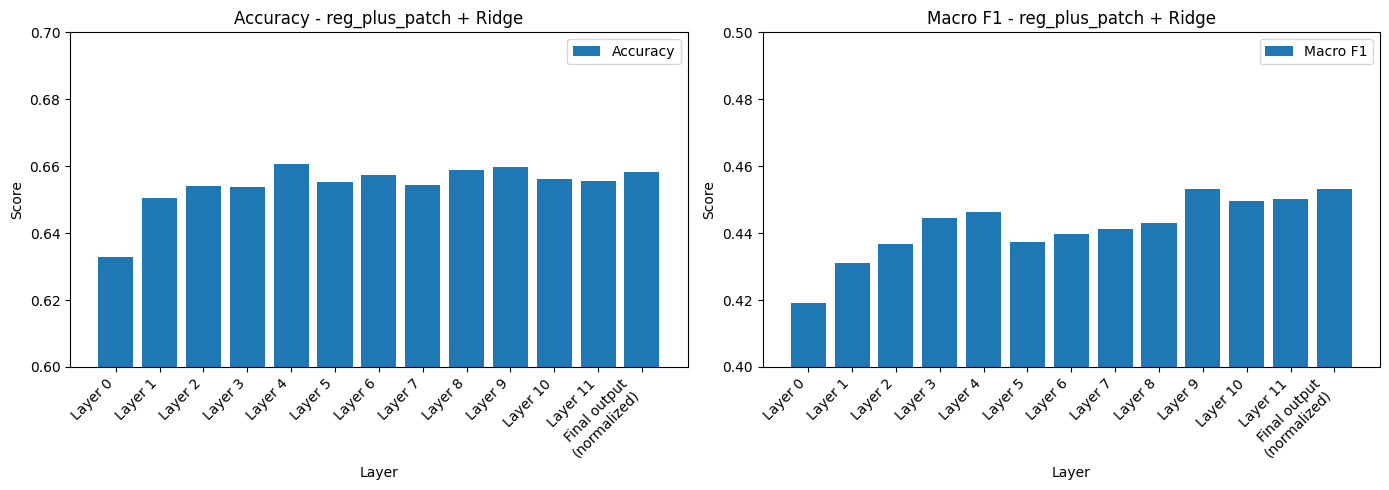

In [55]:
# Plot: reg_plus_patch / Ridge
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_labels = [
    "Final output\n(normalized)" if x == -1 else f"Layer {x}"
    for x in layer_idx_list
]

# Accuracy
axes[0].bar(range(len(layer_idx_list)), acc_rxgb, label="Accuracy")
axes[0].set_ylim(0.6, 0.7)
axes[0].set_xticks(range(len(layer_idx_list)))
axes[0].set_xticklabels(x_labels, rotation=45, ha="right")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Score")
axes[0].set_title("Accuracy - reg + Ridge")
axes[0].legend()

# Macro F1
axes[1].bar(range(len(layer_idx_list)), f1_rxgb, label="Macro F1")
axes[1].set_ylim(0.4, 0.5)
axes[1].set_xticks(range(len(layer_idx_list)))
axes[1].set_xticklabels(x_labels, rotation=45, ha="right")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Score")
axes[1].set_title("Macro F1 - reg + Ridge")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_ablation_reg_ridge.png", dpi=150, bbox_inches="tight")
plt.show()

### xgboost

In [61]:
results_reg_xgb = {}
acc_rxgb, f1_rxgb, bacc_rxgb = [], [], []

for layer in layer_idx_list:
    print(f"\nLayer {layer}")

    extractor = Chronos2FeatureExtractor(
        input_channels=N_CH, chronos_model_name="amazon/chronos-2",
        layer_idx=layer, pool_mode="reg",
        batch_size_embed=256, drop_mask_token=False,
    ).to(device)

    X_tr, y_tr = get_all_embeddings(train_loader, extractor, device)
    X_te, y_te = get_all_embeddings(test_loader,  extractor, device)

    C_tr = clean(np.concatenate([X_tr, hc_train], axis=1))
    C_te = clean(np.concatenate([X_te, hc_test],  axis=1))

    classes = np.unique(y_tr)
    wts = compute_class_weight("balanced", classes=classes, y=y_tr)
    sw = np.array([dict(zip(classes, wts))[y] for y in y_tr], dtype=np.float32)

    xgb_clf = XGBClassifier(
        n_estimators=25, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=SEED, tree_method="hist", eval_metric="mlogloss",
    )
    xgb_clf.fit(C_tr, y_train, sample_weight=sw)
    y_pred = xgb_clf.predict(C_te)

    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average="macro")
    bacc = balanced_accuracy_score(y_te, y_pred)

    acc_rxgb.append(acc); f1_rxgb.append(f1); bacc_rxgb.append(bacc)
    results_reg_xgb[layer] = dict(accuracy=acc, macro_f1=f1, balanced_accuracy=bacc)
    print(f"  acc={acc:.4f}  bacc={bacc:.4f}  macro_f1={f1:.4f}")

    del extractor; gc.collect(); torch.cuda.empty_cache()



Layer 0
Extracting embeddings...
Extracting embeddings...
  acc=0.6411  bacc=0.5219  macro_f1=0.5213

Layer 1
Extracting embeddings...
Extracting embeddings...
  acc=0.6492  bacc=0.5505  macro_f1=0.5390

Layer 2
Extracting embeddings...
Extracting embeddings...
  acc=0.6395  bacc=0.5257  macro_f1=0.5180

Layer 3
Extracting embeddings...
Extracting embeddings...
  acc=0.6363  bacc=0.5160  macro_f1=0.5106

Layer 4
Extracting embeddings...
Extracting embeddings...
  acc=0.6306  bacc=0.5262  macro_f1=0.5256

Layer 5
Extracting embeddings...
Extracting embeddings...
  acc=0.6431  bacc=0.5109  macro_f1=0.5162

Layer 6
Extracting embeddings...
Extracting embeddings...
  acc=0.6492  bacc=0.5139  macro_f1=0.5170

Layer 7
Extracting embeddings...
Extracting embeddings...
  acc=0.6521  bacc=0.5390  macro_f1=0.5347

Layer 8
Extracting embeddings...
Extracting embeddings...
  acc=0.6533  bacc=0.5330  macro_f1=0.5289

Layer 9
Extracting embeddings...
Extracting embeddings...
  acc=0.6484  bacc=0.52

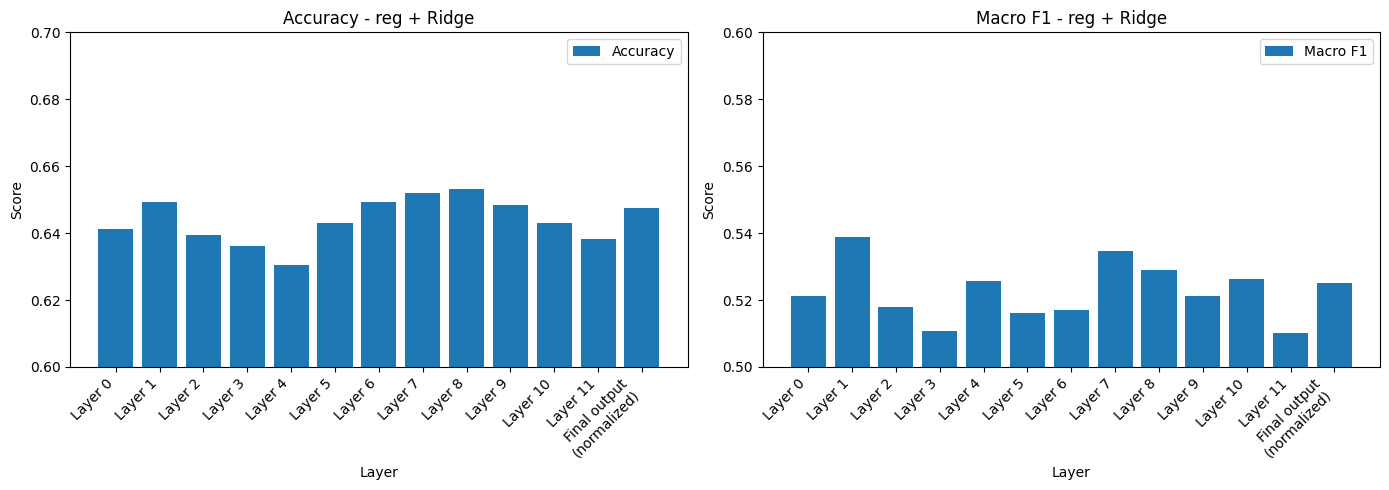

In [63]:
# Plot: reg / XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_labels = [
    "Final output\n(normalized)" if x == -1 else f"Layer {x}"
    for x in layer_idx_list
]

# Accuracy
axes[0].bar(range(len(layer_idx_list)), acc_rxgb, label="Accuracy")
axes[0].set_ylim(0.6, 0.7)
axes[0].set_xticks(range(len(layer_idx_list)))
axes[0].set_xticklabels(x_labels, rotation=45, ha="right")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Score")
axes[0].set_title("Accuracy - reg + Ridge")
axes[0].legend()

# Macro F1
axes[1].bar(range(len(layer_idx_list)), f1_rxgb, label="Macro F1")
axes[1].set_ylim(0.5, 0.6)
axes[1].set_xticks(range(len(layer_idx_list)))
axes[1].set_xticklabels(x_labels, rotation=45, ha="right")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Score")
axes[1].set_title("Macro F1 - reg + Ridge")
axes[1].legend()

plt.tight_layout()
plt.savefig("fig_ablation_reg_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

## 4.4 Summary: Layer Ablation Across Pooling Strategies

### Ridge

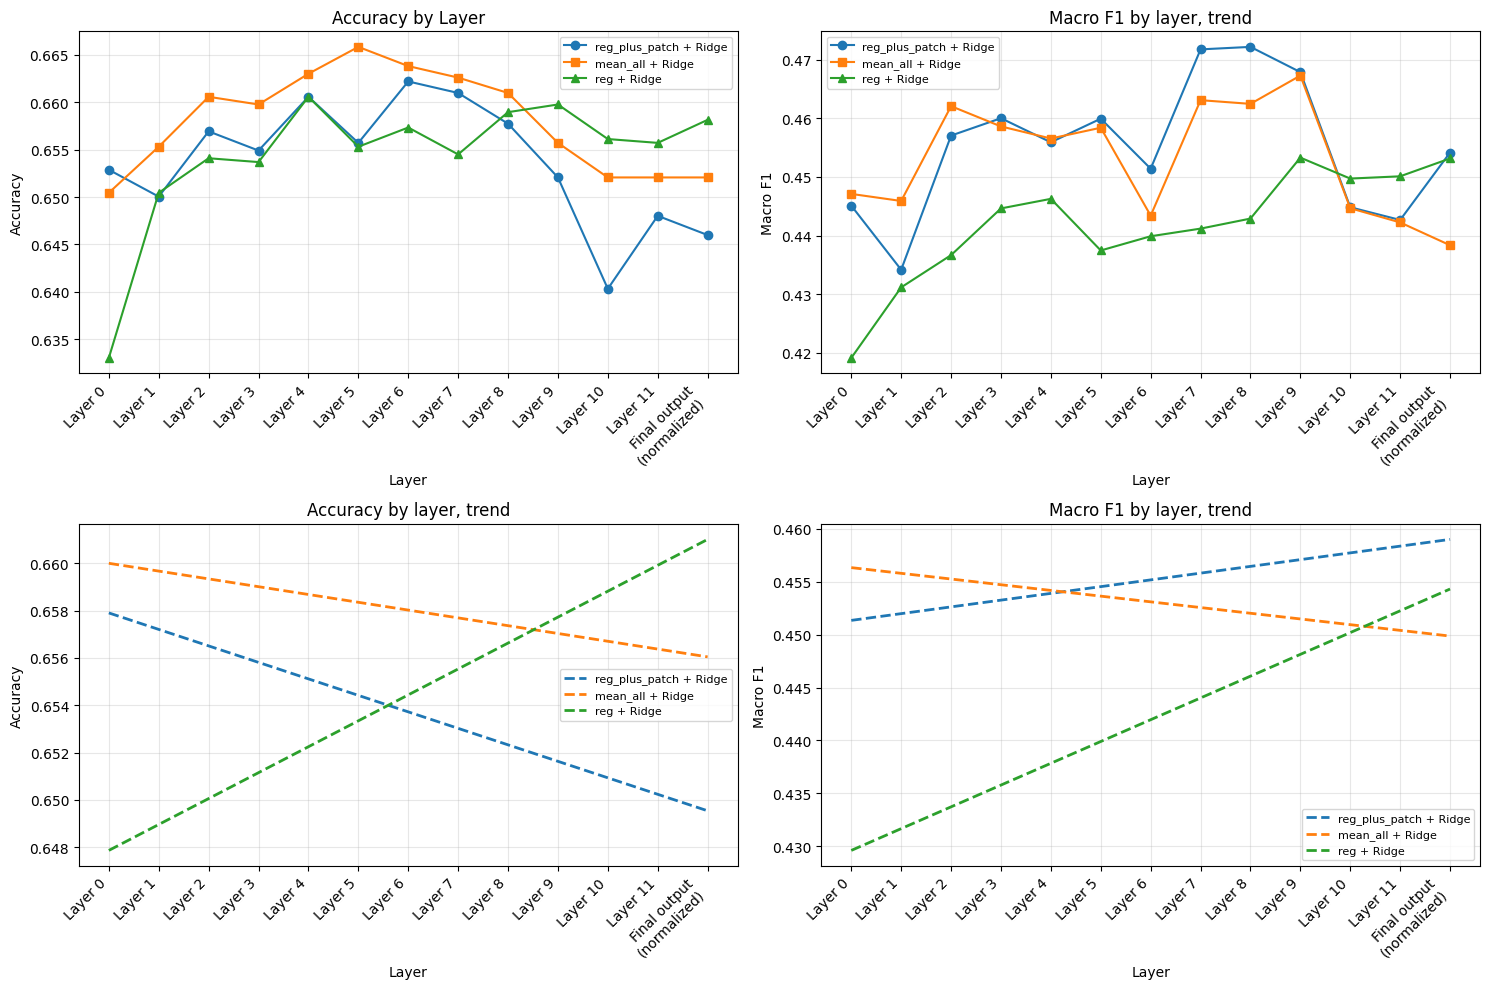

In [41]:
ordered_layers = [x for x in layer_idx_list if x != -1] + [-1]
order_idx = [layer_idx_list.index(x) for x in ordered_layers]

acc_rpr_ord = [acc_rpr[i] for i in order_idx]
acc_mar_ord = [acc_mar[i] for i in order_idx]
acc_rxgb_ord = [acc_rxgb[i] for i in order_idx]

f1_rpr_ord = [f1_rpr[i] for i in order_idx]
f1_mar_ord = [f1_mar[i] for i in order_idx]
f1_rxgb_ord = [f1_rxgb[i] for i in order_idx]

x_pos = np.arange(len(ordered_layers))

x_labels = [
    "Final output\n(normalized)" if v == -1 else f"Layer {v}"
    for v in ordered_layers
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy
axes[0, 0].plot(x_pos, acc_rpr_ord, marker="o", label="reg_plus_patch + Ridge")
axes[0, 0].plot(x_pos, acc_mar_ord, marker="s", label="mean_all + Ridge")
axes[0, 0].plot(x_pos, acc_rxgb_ord, marker="^", label="reg + Ridge")
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(x_labels, rotation=45, ha="right")
axes[0, 0].set_xlabel("Layer")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].set_title("Accuracy by layer")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.3)

# Macro F1
axes[0, 1].plot(x_pos, f1_rpr_ord, marker="o", label="reg_plus_patch + Ridge")
axes[0, 1].plot(x_pos, f1_mar_ord, marker="s", label="mean_all + Ridge")
axes[0, 1].plot(x_pos, f1_rxgb_ord, marker="^", label="reg + Ridge")
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(x_labels, rotation=45, ha="right")
axes[0, 1].set_xlabel("Layer")
axes[0, 1].set_ylabel("Macro F1")
axes[0, 1].set_title("Macro F1 by layer, trend")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(alpha=0.3)

# Accuracy (trends)
axes[1, 0].plot(
    x_pos, np.poly1d(np.polyfit(x_pos, acc_rpr_ord, 1))(x_pos),
    linestyle="--", linewidth=2, label="reg_plus_patch + Ridge"
)
axes[1, 0].plot(
    x_pos, np.poly1d(np.polyfit(x_pos, acc_mar_ord, 1))(x_pos),
    linestyle="--", linewidth=2, label="mean_all + Ridge"
)
axes[1, 0].plot(
    x_pos, np.poly1d(np.polyfit(x_pos, acc_rxgb_ord, 1))(x_pos),
    linestyle="--", linewidth=2, label="reg + Ridge"
)
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(x_labels, rotation=45, ha="right")
axes[1, 0].set_xlabel("Layer")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].set_title("Accuracy by layer, trend")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.3)

# Macro F1 (trends)
axes[1, 1].plot(
    x_pos, np.poly1d(np.polyfit(x_pos, f1_rpr_ord, 1))(x_pos),
    linestyle="--", linewidth=2, label="reg_plus_patch + Ridge"
)
axes[1, 1].plot(
    x_pos, np.poly1d(np.polyfit(x_pos, f1_mar_ord, 1))(x_pos),
    linestyle="--", linewidth=2, label="mean_all + Ridge"
)
axes[1, 1].plot(
    x_pos, np.poly1d(np.polyfit(x_pos, f1_rxgb_ord, 1))(x_pos),
    linestyle="--", linewidth=2, label="reg + Ridge"
)
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(x_labels, rotation=45, ha="right")
axes[1, 1].set_xlabel("Layer")
axes[1, 1].set_ylabel("Macro F1")
axes[1, 1].set_title("Macro F1 by layer, trend")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig_ablation_combined_raw_and_trends.png", dpi=150, bbox_inches="tight")
plt.show()

### xgboost

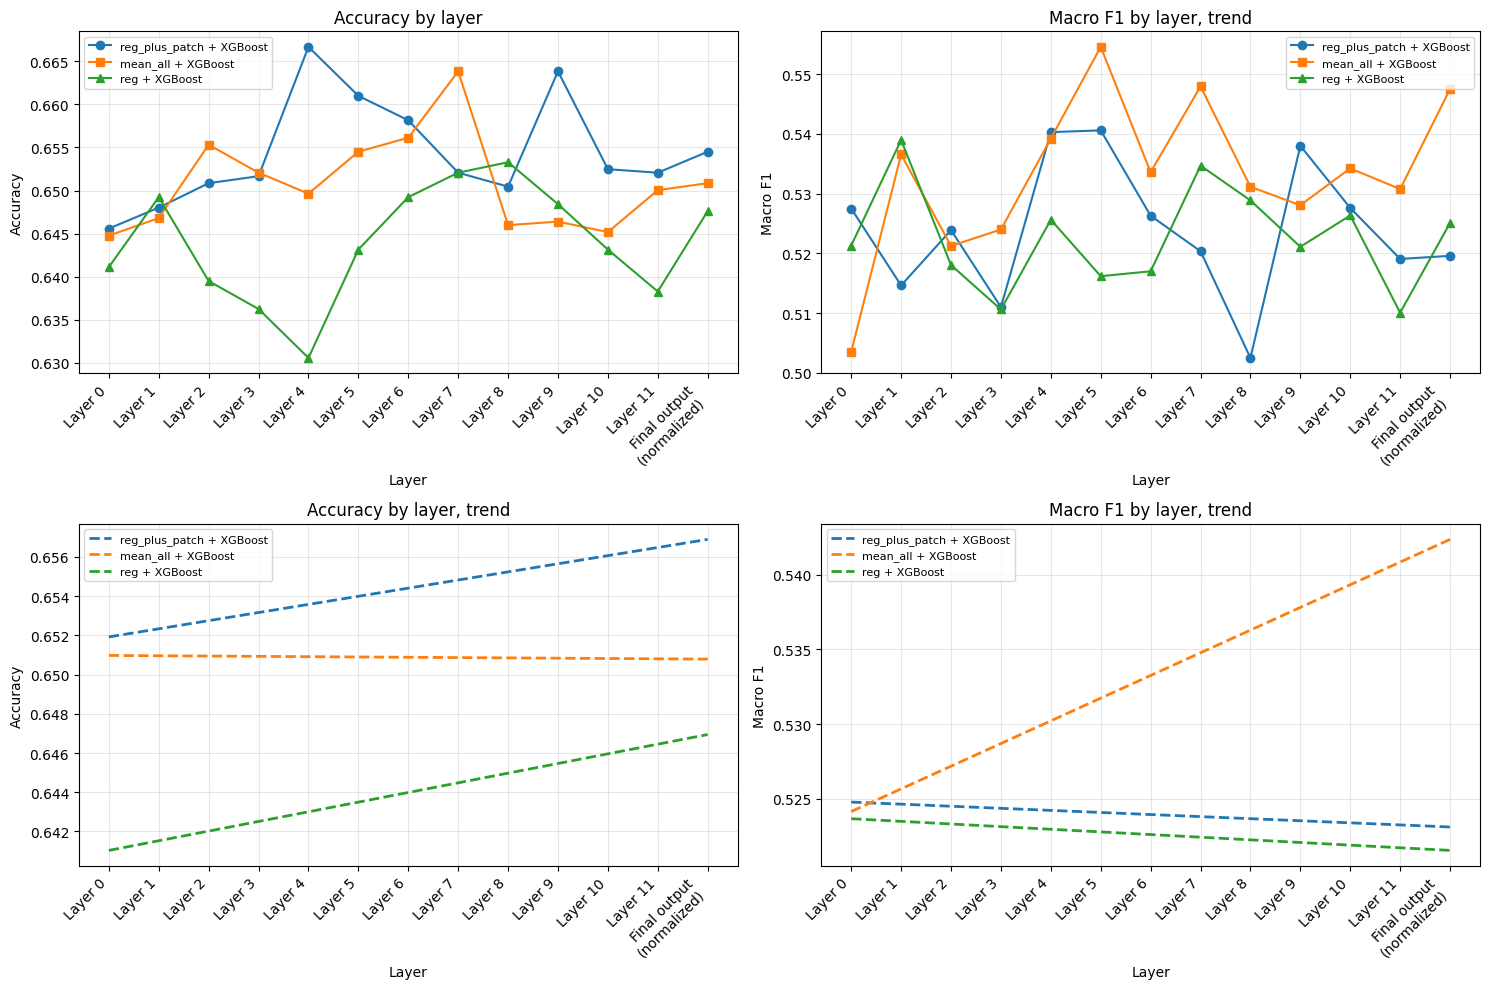

In [69]:
ordered_layers = [x for x in layer_idx_list if x != -1] + [-1]
order_idx = [layer_idx_list.index(x) for x in ordered_layers]

acc_rpr_ord = [acc_rpr[i] for i in order_idx]
acc_mar_ord = [acc_mar[i] for i in order_idx]
acc_rxgb_ord = [acc_rxgb[i] for i in order_idx]

f1_rpr_ord = [f1_rpr[i] for i in order_idx]
f1_mar_ord = [f1_mar[i] for i in order_idx]
f1_rxgb_ord = [f1_rxgb[i] for i in order_idx]

x_pos = np.arange(len(ordered_layers))

x_labels = [
    "Final output\n(normalized)" if v == -1 else f"Layer {v}"
    for v in ordered_layers
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy
axes[0, 0].plot(x_pos, acc_rpr_ord, marker="o", label="reg_plus_patch + XGBoost")
axes[0, 0].plot(x_pos, acc_mar_ord, marker="s", label="mean_all + XGBoost")
axes[0, 0].plot(x_pos, acc_rxgb_ord, marker="^", label="reg + XGBoost")
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(x_labels, rotation=45, ha="right")
axes[0, 0].set_xlabel("Layer")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].set_title("Accuracy by layer")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(alpha=0.3)

# Macro F1
axes[0, 1].plot(x_pos, f1_rpr_ord, marker="o", label="reg_plus_patch + XGBoost")
axes[0, 1].plot(x_pos, f1_mar_ord, marker="s", label="mean_all + XGBoost")
axes[0, 1].plot(x_pos, f1_rxgb_ord, marker="^", label="reg + XGBoost")
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(x_labels, rotation=45, ha="right")
axes[0, 1].set_xlabel("Layer")
axes[0, 1].set_ylabel("Macro F1")
axes[0, 1].set_title("Macro F1 by layer, trend")
axes[0, 1].legend(fontsize=8)
axes[0, 1].grid(alpha=0.3)

# Accuracy (trends)
axes[1, 0].plot(
    x_pos, np.poly1d(np.polyfit(x_pos, acc_rpr_ord, 1))(x_pos),
    linestyle="--", linewidth=2, label="reg_plus_patch + XGBoost"
)
axes[1, 0].plot(
    x_pos, np.poly1d(np.polyfit(x_pos, acc_mar_ord, 1))(x_pos),
    linestyle="--", linewidth=2, label="mean_all + XGBoost"
)
axes[1, 0].plot(
    x_pos, np.poly1d(np.polyfit(x_pos, acc_rxgb_ord, 1))(x_pos),
    linestyle="--", linewidth=2, label="reg + XGBoost"
)
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(x_labels, rotation=45, ha="right")
axes[1, 0].set_xlabel("Layer")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].set_title("Accuracy by layer, trend")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.3)

# Macro F1 (trends)
axes[1, 1].plot(
    x_pos, np.poly1d(np.polyfit(x_pos, f1_rpr_ord, 1))(x_pos),
    linestyle="--", linewidth=2, label="reg_plus_patch + XGBoost"
)
axes[1, 1].plot(
    x_pos, np.poly1d(np.polyfit(x_pos, f1_mar_ord, 1))(x_pos),
    linestyle="--", linewidth=2, label="mean_all + XGBoost"
)
axes[1, 1].plot(
    x_pos, np.poly1d(np.polyfit(x_pos, f1_rxgb_ord, 1))(x_pos),
    linestyle="--", linewidth=2, label="reg + XGBoost"
)
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(x_labels, rotation=45, ha="right")
axes[1, 1].set_xlabel("Layer")
axes[1, 1].set_ylabel("Macro F1")
axes[1, 1].set_title("Macro F1 by layer, trend")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig_ablation_combined_raw_and_trends_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

# 5. Best Extractor, last layer, mean_all pooling

Layer 12 with mean pooling over all tokens consistently yields the best trade-off between accuracy and macro F1. We extract the final embeddings here for the downstream classifiers.

In [106]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_extractor = Chronos2FeatureExtractor(
    input_channels=N_CH,
    chronos_model_name="amazon/chronos-2",
    layer_idx=-1,
    pool_mode="mean_all",
    batch_size_embed=256,
    drop_mask_token=False,
).to(device)

print("Extracting train embeddings...")
X_train_emb, y_train_np = get_all_embeddings(train_loader, best_extractor, device)

print("Extracting test embeddings...")
X_test_emb, y_test_np = get_all_embeddings(test_loader, best_extractor, device)

print(f"\nEmbedding train shape : {X_train_emb.shape}")
print(f"Embedding test  shape : {X_test_emb.shape}")


Extracting train embeddings...
Extracting embeddings...
Extracting test embeddings...
Extracting embeddings...

Embedding train shape : (2459, 4608)
Embedding test  shape : (2466, 4608)


In [107]:
# Concatenate with handcrafted features
concat_train = clean(np.concatenate([X_train_emb, hc_train], axis=1))
concat_test  = clean(np.concatenate([X_test_emb,  hc_test],  axis=1))

print(f"Final feature train : {concat_train.shape}")
print(f"Final feature test  : {concat_test.shape}")


Final feature train : (2459, 4724)
Final feature test  : (2466, 4724)


## 5.1 t-SNE Visualisation of Embeddings

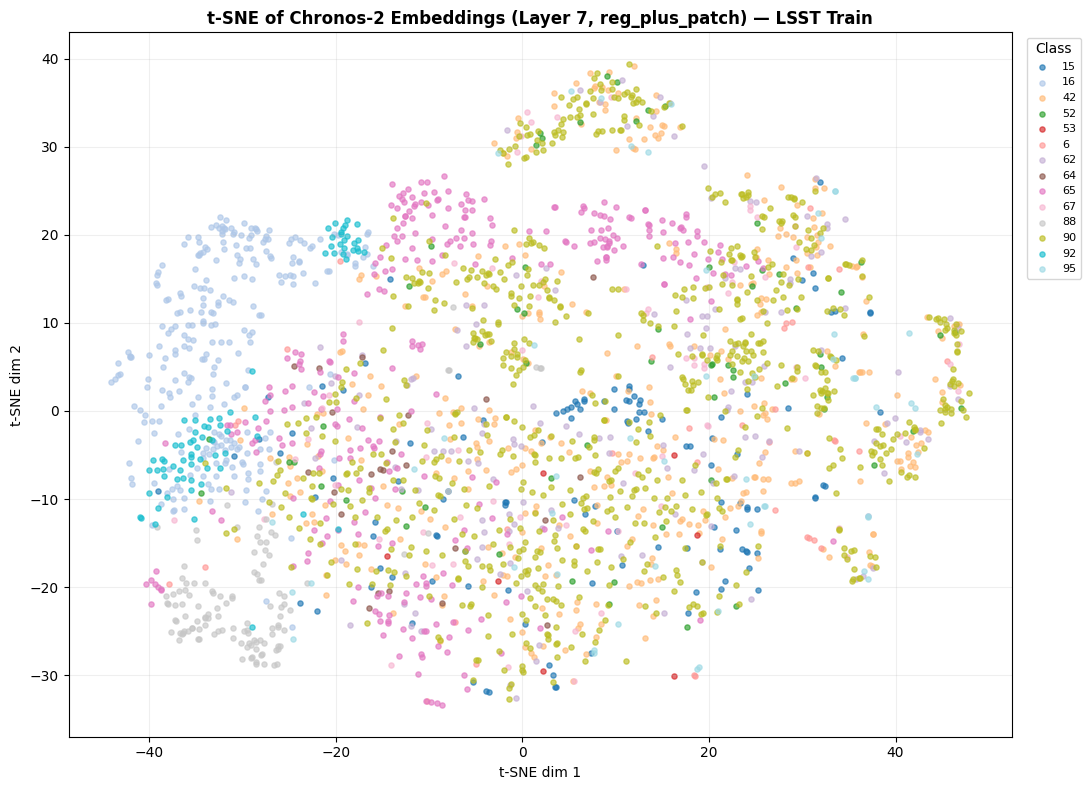

In [108]:
# t-SNE on last layer embeddings (train set)
from sklearn.preprocessing import StandardScaler

emb_scaled = StandardScaler().fit_transform(X_train_emb)
tsne = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
embs_2d = tsne.fit_transform(emb_scaled)

fig, ax = plt.subplots(figsize=(11, 8))
cmap = plt.cm.get_cmap("tab20", N_CLASSES)

for cls_idx in range(N_CLASSES):
    mask = y_train_np == cls_idx
    ax.scatter(embs_2d[mask, 0], embs_2d[mask, 1],
               s=14, alpha=0.65, color=cmap(cls_idx),
               label=str(le.classes_[cls_idx]))

ax.legend(title="Class", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.set_title("t-SNE of Chronos-2 Embeddings (Layer 7, reg_plus_patch) — LSST Train",
             fontsize=12, fontweight="bold")
ax.set_xlabel("t-SNE dim 1"); ax.set_ylabel("t-SNE dim 2")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("fig_tsne_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()


# 6. Probing Classifiers on Chronos-2 Embeddings

Using the embeddings from section 5 (last layer, mean pooling + handcrafted features), we benchmark several downstream classifiers.

In [95]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

best_extractor = Chronos2FeatureExtractor(
    input_channels=N_CH,
    chronos_model_name="amazon/chronos-2",
    layer_idx=-1,
    pool_mode="mean_all",
    batch_size_embed=256,
    drop_mask_token=False,
).to(device)

print("Extracting train embeddings...")
X_train_emb, y_train_np = get_all_embeddings(train_loader, best_extractor, device)

print("Extracting test embeddings...")
X_test_emb, y_test_np = get_all_embeddings(test_loader, best_extractor, device)

print(f"\nEmbedding train shape : {X_train_emb.shape}")
print(f"Embedding test  shape : {X_test_emb.shape}")


Extracting train embeddings...
Extracting embeddings...
Extracting test embeddings...
Extracting embeddings...

Embedding train shape : (2459, 4608)
Embedding test  shape : (2466, 4608)


In [96]:
concat_train = clean(np.concatenate([X_train_emb, hc_train], axis=1))
concat_test  = clean(np.concatenate([X_test_emb,  hc_test],  axis=1))

print(f"Final feature train : {concat_train.shape}")
print(f"Final feature test  : {concat_test.shape}")


Final feature train : (2459, 4724)
Final feature test  : (2466, 4724)


## 6.1 Ridge Classifier

In [97]:
ridge_clf = make_pipeline(StandardScaler(), RidgeClassifierCV(alphas=np.logspace(-3, 3, 13), class_weight="balanced"))
ridge_clf.fit(concat_train, y_train_np)
y_pred_ridge = ridge_clf.predict(concat_test)

print(f"Ridge  | acc={accuracy_score(y_test_np, y_pred_ridge):.4f}  "
      f"bacc={balanced_accuracy_score(y_test_np, y_pred_ridge):.4f}  "
      f"macro_f1={f1_score(y_test_np, y_pred_ridge, average='macro'):.4f}")
print(classification_report(y_test_np, y_pred_ridge, digits=4, zero_division=0))


Ridge  | acc=0.5454  bacc=0.5144  macro_f1=0.4871
              precision    recall  f1-score   support

           0     0.4039    0.6613    0.5015       124
           1     0.9154    0.9222    0.9188       270
           2     0.5066    0.4005    0.4474       382
           3     0.0408    0.0952    0.0571        63
           4     1.0000    0.7143    0.8333         7
           5     0.3077    0.3429    0.3243        35
           6     0.2157    0.2876    0.2465       153
           7     0.0000    0.0000    0.0000        24
           8     0.6982    0.8498    0.7666       313
           9     0.1233    0.2647    0.1682        68
          10     0.8369    0.9752    0.9008       121
          11     0.7253    0.3874    0.5050       777
          12     0.8182    0.9351    0.8727        77
          13     0.2235    0.3654    0.2774        52

    accuracy                         0.5454      2466
   macro avg     0.4868    0.5144    0.4871      2466
weighted avg     0.6125    0.5

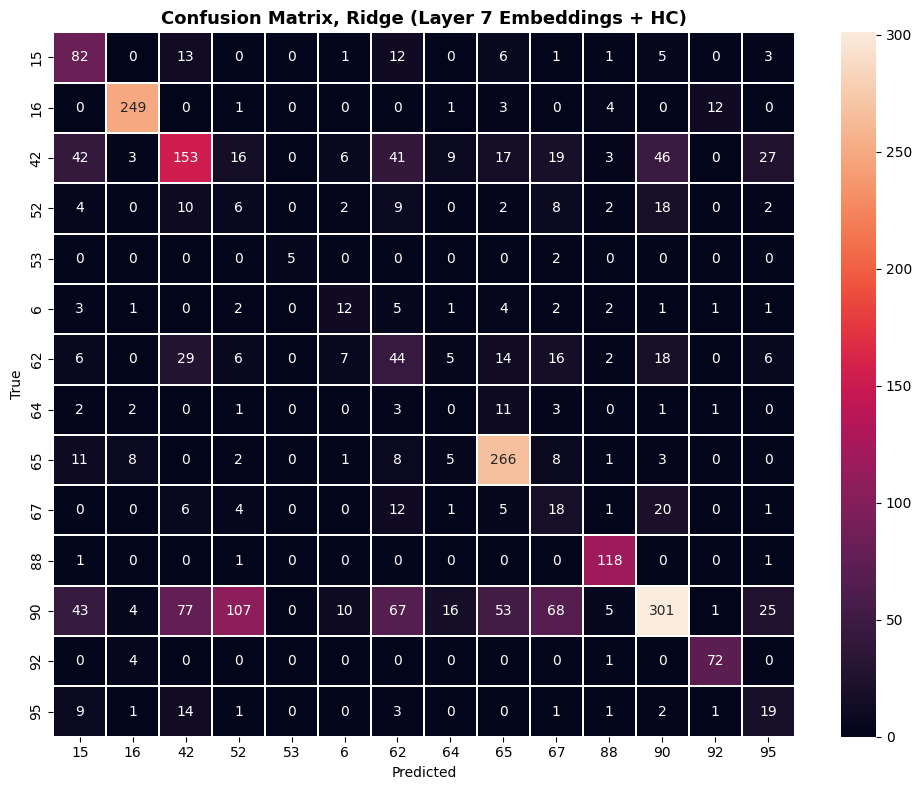

In [98]:
# Confusion matrix, Ridge
cm = confusion_matrix(y_test_np, y_pred_ridge)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax, linewidths=0.3)
ax.set_title("Confusion Matrix, Ridge (Layer 7 Embeddings + HC)", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("fig_cm_ridge.png", dpi=150, bbox_inches="tight")
plt.show()


## 6.2 LightGBM Ensemble (soft voting, 3 seeds)

In [99]:
classes = np.unique(y_train)
wts = compute_class_weight("balanced", classes=classes, y=y_train)
cwd = dict(zip(classes, wts))

seeds = [42, 52, 62]
lgb_models = []

for seed in seeds:
    clf = lgb.LGBMClassifier(
        objective="multiclass", num_class=len(classes), boosting_type="gbdt",
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        class_weight=cwd, random_state=seed, n_jobs=-1, verbosity=-1,
    )
    clf.fit(concat_train, y_train)
    lgb_models.append(clf)

mean_proba = np.mean([m.predict_proba(concat_test) for m in lgb_models], axis=0)
y_pred_lgb = mean_proba.argmax(axis=1)

print(f"LightGBM | acc={accuracy_score(y_test, y_pred_lgb):.4f}  "
      f"bacc={balanced_accuracy_score(y_test, y_pred_lgb):.4f}  "
      f"macro_f1={f1_score(y_test, y_pred_lgb, average='macro'):.4f}")
print(classification_report(y_test, y_pred_lgb, digits=4, zero_division=0))


LightGBM | acc=0.7109  bacc=0.5425  macro_f1=0.5517
              precision    recall  f1-score   support

           0     0.6863    0.5645    0.6195       124
           1     0.9886    0.9630    0.9756       270
           2     0.5573    0.4581    0.5029       382
           3     1.0000    0.0159    0.0312        63
           4     0.7778    1.0000    0.8750         7
           5     0.6923    0.2571    0.3750        35
           6     0.4896    0.3072    0.3775       153
           7     0.0000    0.0000    0.0000        24
           8     0.7254    0.8946    0.8011       313
           9     0.7143    0.1471    0.2439        68
          10     0.9590    0.9669    0.9630       121
          11     0.6603    0.8932    0.7593       777
          12     0.9259    0.9740    0.9494        77
          13     0.6667    0.1538    0.2500        52

    accuracy                         0.7109      2466
   macro avg     0.7031    0.5425    0.5517      2466
weighted avg     0.7069    0

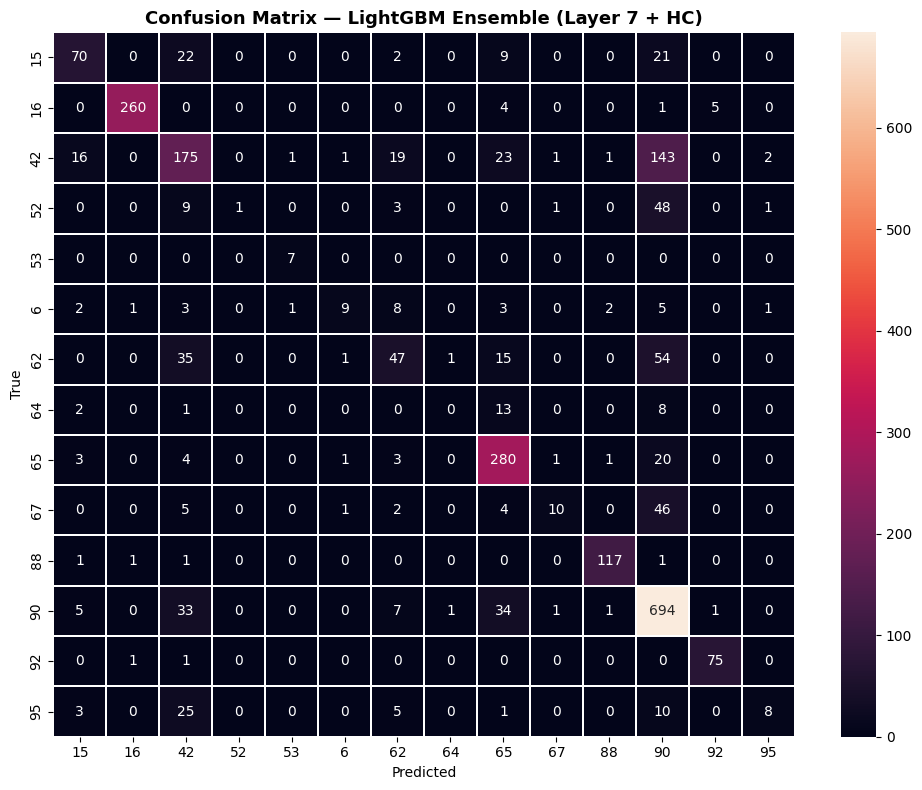

In [104]:
# Confusion matrix, LightGBM
cm = confusion_matrix(y_test, y_pred_lgb)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax, linewidths=0.3)
ax.set_title("Confusion Matrix — LightGBM Ensemble (Layer 7 + HC)", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("fig_cm_lgb.png", dpi=150, bbox_inches="tight")
plt.show()


## 6.3 XGBoost

In [105]:
classes = np.unique(y_train)
wts = compute_class_weight("balanced", classes=classes, y=y_train)
cwd = dict(zip(classes, wts))

sw = np.array([cwd[y] for y in y_train], dtype=np.float32)

xgb_clf = XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.5,
    random_state=SEED, tree_method="hist", eval_metric="mlogloss",
)
xgb_clf.fit(concat_train, y_train, sample_weight=sw)
y_pred_xgb = xgb_clf.predict(concat_test)

print(f"XGBoost  | acc={accuracy_score(y_test, y_pred_xgb):.4f}  "
      f"bacc={balanced_accuracy_score(y_test, y_pred_xgb):.4f}  "
      f"macro_f1={f1_score(y_test, y_pred_xgb, average='macro'):.4f}")
print(classification_report(y_test, y_pred_xgb, digits=4, zero_division=0))


XGBoost  | acc=0.7141  bacc=0.5521  macro_f1=0.5726
              precision    recall  f1-score   support

           0     0.6800    0.5484    0.6071       124
           1     0.9813    0.9704    0.9758       270
           2     0.5822    0.4634    0.5160       382
           3     1.0000    0.0159    0.0312        63
           4     0.8571    0.8571    0.8571         7
           5     0.5789    0.3143    0.4074        35
           6     0.4762    0.3268    0.3876       153
           7     0.2000    0.0833    0.1176        24
           8     0.7361    0.8914    0.8064       313
           9     0.7368    0.2059    0.3218        68
          10     0.9370    0.9835    0.9597       121
          11     0.6660    0.8829    0.7593       777
          12     0.9375    0.9740    0.9554        77
          13     0.6111    0.2115    0.3143        52

    accuracy                         0.7141      2466
   macro avg     0.7129    0.5521    0.5726      2466
weighted avg     0.7113    0

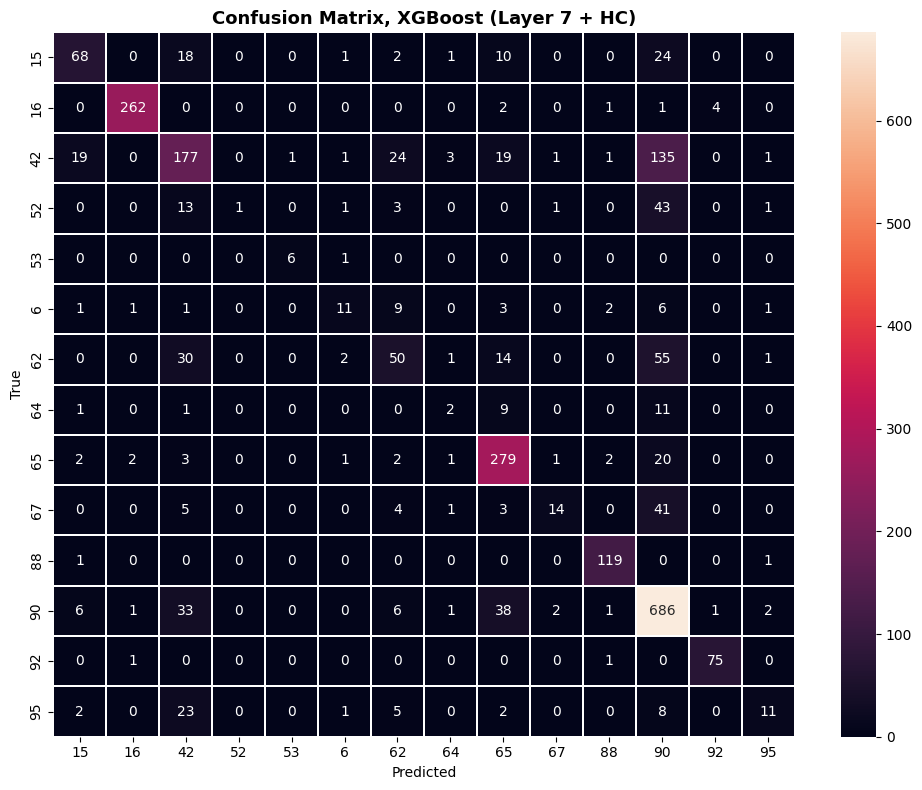

In [109]:
# Confusion matrix, XGBoost
cm = confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax, linewidths=0.3)
ax.set_title("Confusion Matrix, XGBoost (Layer 7 + HC)", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("fig_cm_xgb.png", dpi=150, bbox_inches="tight")
plt.show()

gc.collect(); torch.cuda.empty_cache()


## 6.4 TabICL (in-context learning classifier on PCA-compressed features)

In [53]:
from tabicl import TabICLClassifier

# PCA compression before TabICL
pca_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=512, svd_solver="full", random_state=SEED)),
])
X_tr_tab = pca_pipe.fit_transform(concat_train)
X_te_tab = pca_pipe.transform(concat_test)
print("TabICL input shape:", X_tr_tab.shape)

tabicl_clf = TabICLClassifier(
    support_many_classes=True,
    device="cuda" if torch.cuda.is_available() else "cpu",
    n_estimators=32,
    softmax_temperature=0.7,
    average_logits=False,
    random_state=SEED,
    verbose=True,
    disk_offload_dir="/tmp/tabicl_offload",
)
tabicl_clf.fit(X_tr_tab, y_train_np)
y_pred_tab = tabicl_clf.predict(X_te_tab)

print(f"TabICL   | acc={accuracy_score(y_test_np, y_pred_tab):.4f}  "
      f"bacc={balanced_accuracy_score(y_test_np, y_pred_tab):.4f}  "
      f"macro_f1={f1_score(y_test_np, y_pred_tab, average='macro'):.4f}")
print(classification_report(y_test_np, y_pred_tab, digits=4, zero_division=0))

gc.collect(); torch.cuda.empty_cache()


TabICL input shape: (2459, 512)
INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.



tabicl-classifier-v2-20260212.ckpt:   0%|          | 0.00/110M [00:00<?, ?B/s]

The number of classes (14) exceeds the max number of classes (10) natively supported by the model. Therefore, many-class strategy is enabled to perform mixed-radix ensembling during column-wise embedding and hierarchical classification during in-context learning.

Available GPU memory: 21.15GB, seq_len: 4925, estimated batch size for tf_col: 710
Offload decision: mode=GPU (reason=auto_gpu_fits: 9927MB <= 10827MB safe gpu free)
Output size: 9.69GB (repeat=1), CPU free: 44.43GB, GPU free: 21.15GB, Disk free (effective): 67.14GB @ /tmp/tabicl_offload


Processing tf_col:   0%|          | 0/6 [00:00<?, ?batch/s]

OOM with batch_size=710, reducing to 355


...

OOM with batch_size=707, reducing to 353


Processing tf_col:   0%|          | 0/12 [00:00<?, ?batch/s]


Available GPU memory: 11.37GB, seq_len: 516, estimated batch size for tf_row: 3309
Offload decision: mode=GPU (reason=user_gpu_fits: 77MB <= 11639MB gpu free)
Output size: 0.08GB (repeat=1), CPU free: 44.00GB, GPU free: 11.37GB, Disk free (effective): 0.00GB @ None


Processing tf_row:   0%|          | 0/12 [00:00<?, ?batch/s]

TabICL   | acc=0.6809  bacc=0.4667  macro_f1=0.4808
              precision    recall  f1-score   support

           0     0.7397    0.4355    0.5482       124
           1     0.9176    0.9481    0.9326       270
           2     0.5809    0.4136    0.4832       382
           3     0.0000    0.0000    0.0000        63
           4     0.4444    0.5714    0.5000         7
           5     0.7692    0.2857    0.4167        35
           6     0.4500    0.1176    0.1865       153
           7     0.0000    0.0000    0.0000        24
           8     0.7461    0.9105    0.8201       313
           9     0.6000    0.0882    0.1538        68
          10     0.9286    0.9669    0.9474       121
          11     0.5968    0.9086    0.7204       777
          12     0.8529    0.7532    0.8000        77
          13     0.6364    0.1346    0.2222        52

    accuracy                         0.6809      2466
   macro avg     0.5902    0.4667    0.4808      2466
weighted avg     0.6526    0

In [ ]:
# Confusion matrix, TabICL
cm = confusion_matrix(y_test_np, y_pred_tab)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax, linewidths=0.3)
ax.set_title("Confusion Matrix — TabICL (Layer 7 PCA-512 + HC)", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("fig_cm_tabicl.png", dpi=150, bbox_inches="tight")
plt.show()


# 9. Results Summary

All methods compared on the LSST test set.

In [124]:
summary = {
    "Ridge (L12 + HC)":                dict(acc=accuracy_score(y_test_np, y_pred_ridge),
                                           f1=f1_score(y_test_np, y_pred_ridge, average="macro")),
    "LightGBM ensemble (L12 + HC)":    dict(acc=accuracy_score(y_test, y_pred_lgb),
                                           f1=f1_score(y_test, y_pred_lgb, average="macro")),
    "XGBoost (L12 + HC)":              dict(acc=accuracy_score(y_test, y_pred_xgb),
                                           f1=f1_score(y_test, y_pred_xgb, average="macro")),
    "TabICL PCA-512 (L12 + HC)":       dict(acc=accuracy_score(y_test_np, y_pred_tab),
                                           f1=f1_score(y_test_np, y_pred_tab, average="macro")),
}

print(f"{'Method':<35} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 57)
for name, m in summary.items():
    print(f"{name:<35} {m['acc']:>10.4f} {m['f1']:>10.4f}")


Method                                Accuracy   Macro F1
---------------------------------------------------------
Ridge (L12 + HC)                        0.5454     0.4871
LightGBM ensemble (L12 + HC)            0.7109     0.5517
XGBoost (L12 + HC)                      0.7141     0.5726
TabICL PCA-512 (L12 + HC)               0.6809     0.4808


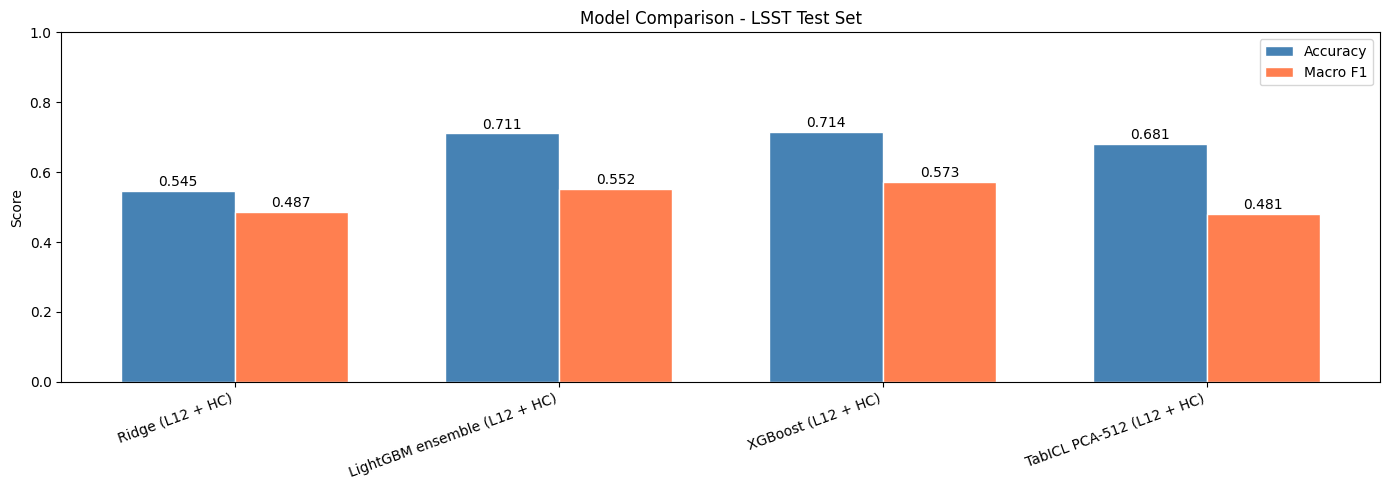

In [125]:
# Bar chart comparison
methods = list(summary.keys())
accs = [summary[m]["acc"] for m in methods]
f1s  = [summary[m]["f1"]  for m in methods]

x = np.arange(len(methods))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
bars1 = ax.bar(x - w/2, accs, w, label="Accuracy",  color="steelblue", edgecolor="white")
bars2 = ax.bar(x + w/2, f1s,  w, label="Macro F1",  color="coral",     edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=20, ha="right")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Score")
ax.set_title("Model Comparison - LSST Test Set")
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.savefig("fig_summary_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
